# Activity Distance: Bootstrap-Corrected Synchrony

This notebook estimates distance-dependent spike synchrony during high-activity periods without using `FiringDistanceAnalyzer`.

The central measurement is conditional firing probability:

```text
P(target electrode fires near reference electrode spike | reference electrode spike, high-activity period)
```

It then subtracts a within-interval jitter null so high baseline firing during active states is not mistaken for fine-timescale synchrony. The output is progression-ready: the same code can run one well, all wells for one DIV, or all configured wells over multiple DIVs.

In [62]:
%matplotlib inline

import os
import sys
import pickle
import warnings
import hashlib
import json
from pathlib import Path

import numpy as np
warnings.filterwarnings("ignore", message="Pandas requires version .* of 'numexpr'.*")
warnings.filterwarnings("ignore", message="Pandas requires version .* of 'bottleneck'.*")
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import f as f_distribution

repo_root = Path.cwd()
if not (repo_root / "ephax").exists() and (repo_root.parent / "ephax").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.environ.setdefault("MPLCONFIGDIR", str((repo_root / ".mpl-cache").resolve()))

import matplotlib.pyplot as plt

from ephax import PrepConfig, RestingActivityDataset
from ephax.metrics import (
    build_highres_traces,
    build_participation_activity_state,
    build_population_ifr,
    detect_high_activity_epochs,
    detect_participation_burst_epochs,
)
from ephax.modeling import HDMEADifferentiationConfig, correlation_function

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 120)
np.random.seed(0)

## Configuration

`SMOKE_MODE=True` keeps the first run small. Set it to `False` for the production settings immediately below it. The effective settings are included in the cache key, so smoke and production outputs are stored separately.

In [63]:
# Dataset switch: "stim_removal_null" or "raw_h5".
DATASET = "stim_removal_null"

# Scope switch: "single_recording", "single_div_all_wells", or "div_progression".
RUN_MODE = "div_progression"

# Single-recording selection. DIV is used by stimRemovalNull and ignored for raw H5.
WELL = 0
DIV = 12
DIVS = [12,14,21,22,23]
RAW_H5_DIV = 40

STIM_DATA_ROOT = repo_root / "ephax/data/stimRemovalNull"
STIM_DATA_FILENAME_TEMPLATE = "DIV{div}_240703_data_well{well}_exp_data.npz"

H5_FILE_INFO = {
    0: ("ephax/data", "well_0.raw.h5", 0),
    1: ("ephax/data", "well_1.raw.h5", 1),
    2: ("ephax/data", "well_2_3.raw.h5", 2),
    3: ("ephax/data", "well_2_3.raw.h5", 3),
    4: ("ephax/data", "well_4.raw.h5", 4),
    5: ("ephax/data", "well_5.raw.h5", 5),
}

AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
AGGREGATE_DIVS = DIVS

START_SEC = 0.0
END_SEC = 300.0 if DATASET == "stim_removal_null" else 600.0
MIN_AMP = 0.0

# Some stimRemovalNull NPZ files store absolute experiment times rather than times starting near 0.
# If the requested absolute window contains no spikes, shift [START_SEC, END_SEC] to the file spike onset.
AUTO_ALIGN_EMPTY_WINDOW_TO_SPIKE_ONSET = True

TOP_START = 0
TOP_STOP = 1000 if DATASET == "stim_removal_null" else 300

# High-activity settings aligned with burst_analysis.ipynb.
IFR_GRID_HZ = 50.0
SMOOTH_SIGMA_SEC = 0.15
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0

# Burst exclusion/isolation uses participation bursts inside high-activity periods.
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0

# Temporal subsetting for synchrony.
# Use "high_activity" to analyze all high-activity periods, "burst" to analyze burst periods only,
# or "high_activity_non_burst" to remove burst periods from high-activity periods.
TEMPORAL_SUBSET = "burst"
TEMPORAL_SUBSET_ALIASES = {
    "high_activity": "high_activity_all",
    "high_activity_all": "high_activity_all",
    "high_activity_non_burst": "high_activity_non_burst",
    "burst": "burst",
}
if TEMPORAL_SUBSET not in TEMPORAL_SUBSET_ALIASES:
    raise ValueError(f"TEMPORAL_SUBSET must be one of {sorted(TEMPORAL_SUBSET_ALIASES)}")
SYNC_ACTIVITY_SCOPE = TEMPORAL_SUBSET_ALIASES[TEMPORAL_SUBSET]

PRIMARY_LAG_WINDOW_MS = (-2.0, 2.0)
DIRECTED_LAG_WINDOWS_MS = [(0.0, 5.0), (5.0, 10.0)]
# Computing all directed windows multiplies runtime; keep False until the primary synchrony curve looks sane.
SYNC_EVALUATE_DIRECTED_LAG_WINDOWS = True
SYNC_LAG_WINDOWS_MS = [PRIMARY_LAG_WINDOW_MS] + (DIRECTED_LAG_WINDOWS_MS if SYNC_EVALUATE_DIRECTED_LAG_WINDOWS else [])
# Fast default: interval-rate expectation preserves each interval's target event probability.
# Slower confirmatory option: "interval_jitter".
SYNC_NULL_METHOD = "interval_jitter"  # "rate_expectation" or "interval_jitter"
SYNC_JITTER_MS = 25.0
SYNC_BOOTSTRAP_REPS = 200
SYNC_N_SURROGATES = 100
SYNC_N_REF_ELECTRODES = 150
SYNC_N_TARGET_ELECTRODES = 300
# Matrix mode is much faster than pair-loop mode: it builds binary spike matrices
# per interval and computes all pair coincidences with matrix multiplication.
SYNC_COMPUTE_METHOD = "matrix"  # "matrix" or "pair_loop"
SYNC_MATRIX_BIN_MS = 1.0

# Pair-loop fallback settings. Matrix mode ignores pair sampling and uses all pairs.
SYNC_PAIR_SAMPLING = "distance_stratified"  # "distance_stratified" or "random_ref_target"
SYNC_PAIRS_PER_DISTANCE_BIN = 250
SYNC_MIN_TRIGGER_SPIKES = 5
SYNC_NULL_STD_FLOOR = 1e-4
SYNC_RANDOM_SEED = 0

# Distance binning.
MIN_DISTANCE_UM = 50.0
MAX_DISTANCE_UM = 3500.0
DISTANCE_BIN_UM = 100.0
MIN_PAIRS_PER_DISTANCE_BIN = 20

# Use the exact Figure 1 correlation-wave definition. Frequency and velocities fix
# its 2539.68 um spatial wavelength. The attenuation lengths below are optimizer
# starting points only: both are fitted from the synchrony data.
MODEL_INITIAL_LAMBDA_EPH_UM = 3000.0
MODEL_INITIAL_AXONAL_DECAY_UM = 200.0
FIGURE1_WAVE_CONFIG = HDMEADifferentiationConfig(
    hz=45.0,
    v_eph_m_s=0.1,
    v_ax_m_s=0.8,
    lambda_eph_um=MODEL_INITIAL_LAMBDA_EPH_UM,
    axonal_decay_um=MODEL_INITIAL_AXONAL_DECAY_UM,
)
MODEL_FIT_BOOTSTRAP_REPS = 1000
MODEL_FIT_RANDOM_SEED = 0

OUTPUT_ROOT = repo_root / "outputs" / "activity_distance"
FORCE_RECOMPUTE = False

# First-run settings. Disable for production.
SMOKE_MODE = True
if SMOKE_MODE:
    SYNC_BOOTSTRAP_REPS = 5
    SYNC_N_SURROGATES = 5 if SYNC_NULL_METHOD == "rate_expectation" else 5
    SYNC_N_REF_ELECTRODES = 30
    SYNC_N_TARGET_ELECTRODES = 60

## Recording Specs and Loaders

In [64]:
def stim_recording_path(well, div):
    return STIM_DATA_ROOT / f"well{int(well)}" / STIM_DATA_FILENAME_TEMPLATE.format(div=int(div), well=int(well))


def build_recording_spec(well, div=None):
    if DATASET == "stim_removal_null":
        div = DIV if div is None else int(div)
        path = stim_recording_path(well, div)
        if not path.exists():
            raise FileNotFoundError(f"Could not find stimRemovalNull recording file: {path}")
        return {
            "dataset": DATASET,
            "source": "npz",
            "path": path,
            "well": int(well),
            "div": int(div),
            "recording_id": f"stimRemovalNull_well{int(well)}_DIV{int(div)}",
            "label": f"stimRemovalNull well{int(well)} DIV{int(div)}",
            "source_file": path.name,
        }

    if DATASET == "raw_h5":
        if int(well) not in H5_FILE_INFO:
            raise ValueError(f"Unsupported raw H5 WELL={well}; available wells: {sorted(H5_FILE_INFO)}")
        h5_folder, h5_filename, h5_well_index = H5_FILE_INFO[int(well)]
        folder_path = repo_root / h5_folder
        file_path = folder_path / h5_filename
        if not file_path.exists():
            raise FileNotFoundError(f"Could not find raw H5 recording file: {file_path}")
        return {
            "dataset": DATASET,
            "source": "h5",
            "folder": folder_path,
            "filename": h5_filename,
            "path": file_path,
            "well": int(well),
            "h5_well_index": int(h5_well_index),
            "div": int(RAW_H5_DIV),
            "recording_id": f"raw_h5_well{int(well)}_DIV{int(RAW_H5_DIV)}",
            "label": f"raw H5 well{int(well)} DIV{int(RAW_H5_DIV)}",
            "source_file": h5_filename,
        }

    raise ValueError("DATASET must be 'stim_removal_null' or 'raw_h5'.")


def iter_recording_specs():
    if RUN_MODE == "single_recording":
        yield build_recording_spec(WELL, DIV)
        return

    if RUN_MODE == "single_div_all_wells":
        divs = [DIV]
        wells = AGGREGATE_WELLS
    elif RUN_MODE == "div_progression":
        divs = list(DIVS)
        wells = AGGREGATE_WELLS
    else:
        raise ValueError("RUN_MODE must be 'single_recording', 'single_div_all_wells', or 'div_progression'.")

    for div in divs:
        for well in wells:
            try:
                yield build_recording_spec(well, div)
            except FileNotFoundError as exc:
                print(f"Skipping missing recording: {exc}")


def npz_spike_time_range(path, min_amp=MIN_AMP):
    data = np.load(path, allow_pickle=True)
    sf = float(data["samp_rate"])
    spikes = data["spike_data"]
    times = np.asarray(spikes["frameno"], dtype=float) / sf
    amplitudes = np.abs(np.asarray(spikes["amplitude"], dtype=float))
    valid = np.isfinite(times) & (amplitudes >= float(min_amp))
    if not np.any(valid):
        return np.nan, np.nan, 0
    return float(np.nanmin(times[valid])), float(np.nanmax(times[valid])), int(np.count_nonzero(valid))


def resolve_recording_window_for_spec(spec, start_sec=START_SEC, end_sec=END_SEC, min_amp=MIN_AMP):
    start = float(start_sec)
    end = float(end_sec)
    if spec["source"] != "npz" or not AUTO_ALIGN_EMPTY_WINDOW_TO_SPIKE_ONSET:
        return start, end, "configured"

    t_min, t_max, n_spikes = npz_spike_time_range(spec["path"], min_amp=min_amp)
    if n_spikes == 0 or not np.isfinite(t_min) or not np.isfinite(t_max):
        return start, end, "configured_empty_file"

    has_spikes_in_configured_window = (t_max >= start) and (t_min <= end)
    if has_spikes_in_configured_window:
        return start, end, "configured"

    duration = max(0.0, end - start)
    shifted_start = t_min + start
    shifted_end = min(t_max, shifted_start + duration) if duration > 0 else t_max
    if shifted_end <= shifted_start:
        shifted_end = t_max
    return float(shifted_start), float(shifted_end), "shifted_to_spike_onset"


def load_recording_from_spec(spec, start_sec=START_SEC, end_sec=END_SEC, min_amp=MIN_AMP):
    if spec["source"] == "npz":
        resolved_start, resolved_end, window_mode = resolve_recording_window_for_spec(spec, start_sec, end_sec, min_amp)
        spec["resolved_start_sec"] = resolved_start
        spec["resolved_end_sec"] = resolved_end
        spec["window_mode"] = window_mode
        file_info = [(str(spec["path"]), resolved_start, resolved_end, int(spec["well"]))]
        return RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=float(min_amp))

    if spec["source"] == "h5":
        spec["resolved_start_sec"] = float(start_sec)
        spec["resolved_end_sec"] = float(end_sec)
        spec["window_mode"] = "configured"
        file_info = [(str(spec["folder"]), str(spec["filename"]), float(start_sec), float(end_sec), int(spec["h5_well_index"]))]
        return RestingActivityDataset.from_file_info(file_info, source="h5", min_amp=float(min_amp))

    raise ValueError(f"Unsupported source: {spec['source']}")


recording_specs = list(iter_recording_specs())
recording_spec_table = pd.DataFrame(recording_specs)
if recording_spec_table.empty:
    raise ValueError("No recordings were found for the configured scope.")
recording_spec_table[["dataset", "well", "div", "recording_id", "source_file"]]

,dataset,well,div,recording_id,source_file
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,DIV12_240703_data_well0_exp_data.npz
1,stim_removal_null,1,12,stimRemovalNull_well1_DIV12,DIV12_240703_data_well1_exp_data.npz
2,stim_removal_null,2,12,stimRemovalNull_well2_DIV12,DIV12_240703_data_well2_exp_data.npz
3,stim_removal_null,3,12,stimRemovalNull_well3_DIV12,DIV12_240703_data_well3_exp_data.npz
4,stim_removal_null,4,12,stimRemovalNull_well4_DIV12,DIV12_240703_data_well4_exp_data.npz
5,stim_removal_null,5,12,stimRemovalNull_well5_DIV12,DIV12_240703_data_well5_exp_data.npz
6,stim_removal_null,0,14,stimRemovalNull_well0_DIV14,DIV14_240703_data_well0_exp_data.npz
7,stim_removal_null,1,14,stimRemovalNull_well1_DIV14,DIV14_240703_data_well1_exp_data.npz
8,stim_removal_null,2,14,stimRemovalNull_well2_DIV14,DIV14_240703_data_well2_exp_data.npz
9,stim_removal_null,3,14,stimRemovalNull_well3_DIV14,DIV14_240703_data_well3_exp_data.npz


## Interval Detection

In [65]:
def _empty_intervals():
    return pd.DataFrame(columns=["event_idx", "start_time_s", "end_time_s", "duration_s"])


def normalize_intervals(df):
    if df is None or len(df) == 0:
        return _empty_intervals()
    out = df.copy()
    if not {"start_time_s", "end_time_s"}.issubset(out.columns):
        raise ValueError("interval table must contain start_time_s and end_time_s")
    out["start_time_s"] = out["start_time_s"].astype(float)
    out["end_time_s"] = out["end_time_s"].astype(float)
    out = out[np.isfinite(out["start_time_s"]) & np.isfinite(out["end_time_s"])]
    out = out[out["end_time_s"] > out["start_time_s"]]
    out = out.sort_values("start_time_s", ignore_index=True)
    out["duration_s"] = out["end_time_s"] - out["start_time_s"]
    if "event_idx" not in out:
        out["event_idx"] = np.arange(len(out), dtype=int)
    return out


def subtract_intervals(base_df, remove_df):
    base = normalize_intervals(base_df)
    remove = normalize_intervals(remove_df)
    if base.empty or remove.empty:
        return base.copy()

    rows = []
    for _, b in base.iterrows():
        pieces = [(float(b.start_time_s), float(b.end_time_s))]
        overlaps = remove[(remove["end_time_s"] > b.start_time_s) & (remove["start_time_s"] < b.end_time_s)]
        for _, r in overlaps.iterrows():
            new_pieces = []
            rs, re = float(r.start_time_s), float(r.end_time_s)
            for ps, pe in pieces:
                if re <= ps or rs >= pe:
                    new_pieces.append((ps, pe))
                    continue
                if rs > ps:
                    new_pieces.append((ps, min(rs, pe)))
                if re < pe:
                    new_pieces.append((max(re, ps), pe))
            pieces = [(ps, pe) for ps, pe in new_pieces if pe > ps]
        for ps, pe in pieces:
            rows.append({"start_time_s": ps, "end_time_s": pe})
    out = pd.DataFrame(rows)
    if out.empty:
        return _empty_intervals()
    out["event_idx"] = np.arange(len(out), dtype=int)
    out["duration_s"] = out["end_time_s"] - out["start_time_s"]
    return out


def choose_activity_intervals(high_epochs, burst_epochs, scope):
    high_epochs = normalize_intervals(high_epochs)
    burst_epochs = normalize_intervals(burst_epochs)
    if scope == "high_activity_all":
        return high_epochs
    if scope == "burst":
        return burst_epochs
    if scope == "high_activity_non_burst":
        return subtract_intervals(high_epochs, burst_epochs)
    raise ValueError("SYNC_ACTIVITY_SCOPE must be 'high_activity_non_burst', 'high_activity_all', or 'burst'.")


def skipped_recording_result(spec, reason, rec=None, refs=None):
    if rec is not None:
        in_window = (rec.spikes["time"] >= rec.start_time) & (rec.spikes["time"] <= rec.end_time)
        n_spikes = int(np.sum(in_window))
        n_active = int(np.unique(rec.spikes["electrode"][in_window]).size) if n_spikes else 0
    else:
        n_spikes = 0
        n_active = 0
    summary = {
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": spec.get("div", np.nan),
        "recording_id": spec["recording_id"],
        "source_file": spec["source_file"],
        "window_mode": spec.get("window_mode", "unknown"),
        "resolved_start_sec": spec.get("resolved_start_sec", np.nan),
        "resolved_end_sec": spec.get("resolved_end_sec", np.nan),
        "valid_for_sync": False,
        "skip_reason": str(reason),
        "n_spikes": n_spikes,
        "n_active_electrodes": n_active,
        "n_refs": int(len(refs)) if refs is not None else 0,
        "n_high_activity_periods": 0,
        "n_burst_periods": 0,
        "n_selected_periods": 0,
        "selected_duration_s": 0.0,
        "high_activity_threshold_hz": np.nan,
    }
    return {
        "spec": spec,
        "dataset": None,
        "recording": rec,
        "refs": np.asarray([] if refs is None else refs, dtype=int),
        "population": None,
        "high_epochs": _empty_intervals(),
        "burst_epochs": _empty_intervals(),
        "selected_intervals": _empty_intervals(),
        "summary": summary,
    }


def detect_recording_activity(spec):
    try:
        ds = load_recording_from_spec(spec)
    except Exception as exc:
        return skipped_recording_result(spec, f"load failed: {exc}")

    rec = ds.recordings[0]
    prep_cfg = PrepConfig(mode="top", top_start=TOP_START, top_stop=TOP_STOP, verbose=False)
    refs = ds.select_ref_electrodes(prep_cfg)[0]
    if len(refs) == 0:
        return skipped_recording_result(spec, "no selected reference electrodes", rec=rec, refs=refs)

    try:
        population = build_population_ifr(rec, refs, grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC)
    except ValueError as exc:
        return skipped_recording_result(spec, f"population IFR unavailable: {exc}", rec=rec, refs=refs)

    high_epochs, high_info = detect_high_activity_epochs(
        population.time_grid,
        population.mean_ifr_smooth,
        mad_scale=HIGH_ACTIVITY_MAD_SCALE,
        min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
        max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    )

    try:
        highres = build_highres_traces(rec, refs, bin_ms=HIGHRES_BIN_MS, smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS)
        participation = build_participation_activity_state(highres, aggregation_ms=NETWORK_BIN_MS)
        burst_epochs = detect_participation_burst_epochs(
            participation,
            high_epochs,
            min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
            min_duration_ms=NETWORK_MIN_DURATION_MS,
        )
    except ValueError:
        burst_epochs = _empty_intervals()

    selected_intervals = choose_activity_intervals(high_epochs, burst_epochs, SYNC_ACTIVITY_SCOPE)
    selected_intervals = normalize_intervals(selected_intervals)

    in_window = (rec.spikes["time"] >= rec.start_time) & (rec.spikes["time"] <= rec.end_time)
    valid_for_sync = bool(len(selected_intervals) > 0)
    summary = {
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": spec.get("div", np.nan),
        "recording_id": spec["recording_id"],
        "source_file": spec["source_file"],
        "window_mode": spec.get("window_mode", "unknown"),
        "resolved_start_sec": spec.get("resolved_start_sec", np.nan),
        "resolved_end_sec": spec.get("resolved_end_sec", np.nan),
        "valid_for_sync": valid_for_sync,
        "skip_reason": "" if valid_for_sync else f"no intervals for scope {SYNC_ACTIVITY_SCOPE}",
        "n_spikes": int(np.sum(in_window)),
        "n_active_electrodes": int(np.unique(rec.spikes["electrode"][in_window]).size),
        "n_refs": int(len(refs)),
        "n_high_activity_periods": int(len(high_epochs)),
        "n_burst_periods": int(len(burst_epochs)),
        "n_selected_periods": int(len(selected_intervals)),
        "selected_duration_s": float(selected_intervals["duration_s"].sum()) if not selected_intervals.empty else 0.0,
        "high_activity_threshold_hz": float(high_info.get("threshold_hz", np.nan)),
    }
    return {
        "spec": spec,
        "dataset": ds,
        "recording": rec,
        "refs": np.asarray(refs, dtype=int),
        "population": population,
        "high_epochs": normalize_intervals(high_epochs),
        "burst_epochs": normalize_intervals(burst_epochs),
        "selected_intervals": selected_intervals,
        "summary": summary,
    }


all_activity_results = [detect_recording_activity(spec) for spec in recording_specs]
recording_summary = pd.DataFrame([item["summary"] for item in all_activity_results])
activity_results = [item for item in all_activity_results if item["summary"].get("valid_for_sync", False)]
if not activity_results:
    display(recording_summary)
    raise ValueError("No recordings are valid for synchrony analysis. Inspect recording_summary['skip_reason'].")
recording_summary

,dataset,well,div,recording_id,source_file,window_mode,resolved_start_sec,resolved_end_sec,valid_for_sync,skip_reason,n_spikes,n_active_electrodes,n_refs,n_high_activity_periods,n_burst_periods,n_selected_periods,selected_duration_s,high_activity_threshold_hz
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,DIV12_240703_data_well0_exp_data.npz,configured,0.0000,300.0000,True,,129192,998,998,14,66,66,4.81,0.193353
1,stim_removal_null,1,12,stimRemovalNull_well1_DIV12,DIV12_240703_data_well1_exp_data.npz,configured,0.0000,300.0000,True,,108847,1002,1000,11,68,68,4.62,0.125421
2,stim_removal_null,2,12,stimRemovalNull_well2_DIV12,DIV12_240703_data_well2_exp_data.npz,configured,0.0000,300.0000,True,,114568,987,987,15,44,44,2.56,0.200622
3,stim_removal_null,3,12,stimRemovalNull_well3_DIV12,DIV12_240703_data_well3_exp_data.npz,configured,0.0000,300.0000,True,,112949,1001,1000,11,63,63,3.71,0.203911
4,stim_removal_null,4,12,stimRemovalNull_well4_DIV12,DIV12_240703_data_well4_exp_data.npz,configured,0.0000,300.0000,True,,97508,980,980,16,52,52,3.58,0.152112
5,stim_removal_null,5,12,stimRemovalNull_well5_DIV12,DIV12_240703_data_well5_exp_data.npz,configured,0.0000,300.0000,True,,112212,994,994,14,69,69,5.84,0.153437
6,stim_removal_null,0,14,stimRemovalNull_well0_DIV14,DIV14_240703_data_well0_exp_data.npz,configured,0.0000,300.0000,True,,129689,1007,1000,13,65,65,3.14,0.196693
7,stim_removal_null,1,14,stimRemovalNull_well1_DIV14,DIV14_240703_data_well1_exp_data.npz,configured,0.0000,300.0000,True,,113101,1006,1000,13,63,63,2.72,0.271710
8,stim_removal_null,2,14,stimRemovalNull_well2_DIV14,DIV14_240703_data_well2_exp_data.npz,configured,0.0000,300.0000,True,,114901,1006,1000,13,49,49,1.90,0.220177
9,stim_removal_null,3,14,stimRemovalNull_well3_DIV14,DIV14_240703_data_well3_exp_data.npz,configured,0.0000,300.0000,True,,125546,1000,1000,12,72,72,3.51,0.171587


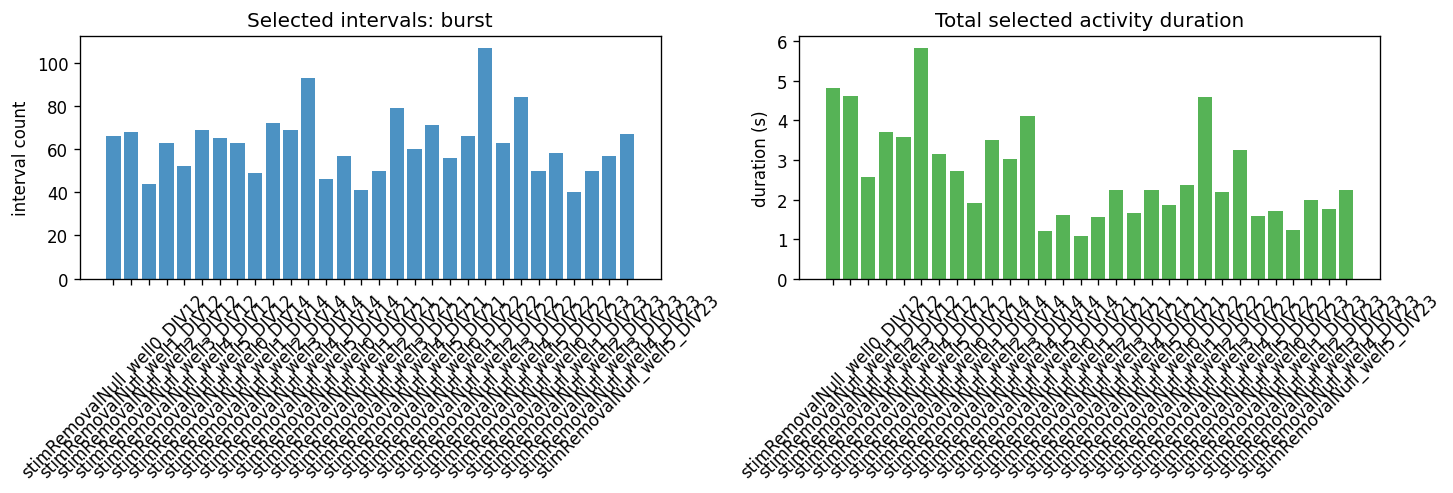

,dataset,well,div,recording_id,interval_kind,event_idx,start_time_s,end_time_s,duration_s
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,0,15.66,21.52,5.86
1,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,1,39.82,44.84,5.02
2,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,2,61.34,66.32,4.98
3,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,3,81.18,87.06,5.88
4,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,4,104.04,109.10,5.06


In [66]:
interval_rows = []
for item in activity_results:
    spec = item["spec"]
    for interval_kind, intervals in [
        ("high_activity", item["high_epochs"]),
        ("burst", item["burst_epochs"]),
        (SYNC_ACTIVITY_SCOPE, item["selected_intervals"]),
    ]:
        for _, row in intervals.iterrows():
            interval_rows.append(
                {
                    "dataset": spec["dataset"],
                    "well": int(spec["well"]),
                    "div": spec.get("div", np.nan),
                    "recording_id": spec["recording_id"],
                    "interval_kind": interval_kind,
                    "event_idx": int(row.get("event_idx", len(interval_rows))),
                    "start_time_s": float(row["start_time_s"]),
                    "end_time_s": float(row["end_time_s"]),
                    "duration_s": float(row["duration_s"]),
                }
            )
interval_summary = pd.DataFrame(interval_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
plot_df = recording_summary.copy()
plot_df["label"] = plot_df["recording_id"].astype(str)
axes[0].bar(plot_df["label"], plot_df["n_selected_periods"], color="tab:blue", alpha=0.8)
axes[0].set_ylabel("interval count")
axes[0].set_title(f"Selected intervals: {SYNC_ACTIVITY_SCOPE}")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(plot_df["label"], plot_df["selected_duration_s"], color="tab:green", alpha=0.8)
axes[1].set_ylabel("duration (s)")
axes[1].set_title("Total selected activity duration")
axes[1].tick_params(axis="x", rotation=45)
plt.show()

interval_summary.head()

## Bootstrap-Corrected Conditional Synchrony

In [67]:
def electrode_coords_um(layout):
    df = pd.DataFrame(layout)
    df = df.dropna(subset=["electrode", "x", "y"])
    return df.drop_duplicates("electrode").set_index("electrode")[["x", "y"]].astype(float)


def distance_edges_and_centers():
    edges = np.arange(MIN_DISTANCE_UM, MAX_DISTANCE_UM + DISTANCE_BIN_UM, DISTANCE_BIN_UM, dtype=float)
    if edges[-1] < MAX_DISTANCE_UM:
        edges = np.append(edges, MAX_DISTANCE_UM)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return edges, centers


def build_pair_arrays(electrodes, coords_df):
    electrodes = np.asarray([int(e) for e in electrodes if int(e) in coords_df.index], dtype=int)
    if electrodes.size < 2:
        return electrodes, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float), np.array([], dtype=int), np.array([], dtype=float)
    xy = coords_df.loc[electrodes, ["x", "y"]].to_numpy(dtype=float)
    diff = xy[:, None, :] - xy[None, :, :]
    dist = np.sqrt(np.sum(diff * diff, axis=2))
    ref_idx, target_idx = np.where(~np.eye(electrodes.size, dtype=bool))
    distance_um = dist[ref_idx, target_idx]
    edges, centers = distance_edges_and_centers()
    bin_idx = np.searchsorted(edges, distance_um, side="right") - 1
    keep = (bin_idx >= 0) & (bin_idx < centers.size)
    return electrodes, ref_idx[keep], target_idx[keep], distance_um[keep], bin_idx[keep], centers


def build_pair_catalog(electrodes, coords_df):
    electrodes, ref_idx, target_idx, distance_um, bin_idx, centers = build_pair_arrays(electrodes, coords_df)
    if ref_idx.size == 0:
        return pd.DataFrame(columns=["ref_electrode", "target_electrode", "distance_um", "distance_bin_idx", "distance_bin_center_um"])
    return pd.DataFrame(
        {
            "ref_electrode": electrodes[ref_idx].astype(int),
            "target_electrode": electrodes[target_idx].astype(int),
            "distance_um": distance_um.astype(float),
            "distance_bin_idx": bin_idx.astype(int),
            "distance_bin_center_um": centers[bin_idx].astype(float),
        }
    )


def interval_spike_matrix(recording, electrodes, start_s, end_s, bin_ms):
    bin_s = float(bin_ms) / 1000.0
    n_bins = int(np.ceil((float(end_s) - float(start_s)) / bin_s))
    if n_bins <= 0:
        return np.zeros((0, len(electrodes)), dtype=np.uint8)
    times = np.asarray(recording.spikes["time"], dtype=float)
    spike_electrodes = np.asarray(recording.spikes["electrode"], dtype=int)
    mask = (times >= float(start_s)) & (times < float(end_s))
    times = times[mask]
    spike_electrodes = spike_electrodes[mask]
    if times.size == 0:
        return np.zeros((n_bins, len(electrodes)), dtype=np.uint8)
    electrode_to_idx = {int(e): i for i, e in enumerate(np.asarray(electrodes, dtype=int))}
    cols = np.fromiter((electrode_to_idx.get(int(e), -1) for e in spike_electrodes), dtype=int, count=spike_electrodes.size)
    valid = cols >= 0
    rows = np.floor((times[valid] - float(start_s)) / bin_s).astype(int)
    cols = cols[valid]
    valid_rows = (rows >= 0) & (rows < n_bins)
    mat = np.zeros((n_bins, len(electrodes)), dtype=np.uint8)
    mat[rows[valid_rows], cols[valid_rows]] = 1
    return mat


def window_spike_matrix(spike_matrix, lag_start_ms, lag_stop_ms, bin_ms):
    lag_start_bins = int(np.floor(float(lag_start_ms) / float(bin_ms)))
    lag_stop_bins = int(np.ceil(float(lag_stop_ms) / float(bin_ms)))
    out = np.zeros_like(spike_matrix, dtype=np.uint8)
    n_time = spike_matrix.shape[0]
    for lag in range(lag_start_bins, lag_stop_bins + 1):
        if lag >= 0:
            if lag < n_time:
                out[: n_time - lag] |= spike_matrix[lag:]
        else:
            shift = -lag
            if shift < n_time:
                out[shift:] |= spike_matrix[: n_time - shift]
    return out


def circular_shift_columns(mat, shifts):
    mat = np.asarray(mat)
    shifts = np.asarray(shifts, dtype=int)
    if mat.size == 0:
        return mat.copy()
    rows = (np.arange(mat.shape[0])[:, None] - shifts[None, :]) % mat.shape[0]
    return mat[rows, np.arange(mat.shape[1])[None, :]]


def aggregate_pair_values_by_distance(values, ref_idx, target_idx, bin_idx, centers, prefix):
    values = np.asarray(values, dtype=float)
    pair_values = values[ref_idx, target_idx]
    finite = np.isfinite(pair_values)
    out = []
    for b in np.unique(bin_idx[finite]):
        vals = pair_values[(bin_idx == b) & finite]
        if vals.size == 0:
            continue
        out.append(
            {
                "distance_bin_idx": int(b),
                "distance_bin_center_um": float(centers[int(b)]),
                f"{prefix}_mean": float(np.nanmean(vals)),
                f"{prefix}_median": float(np.nanmedian(vals)),
                "n_pairs": int(vals.size),
            }
        )
    return pd.DataFrame(out)



def _bin_pair_metrics_from_matrices(metric_matrices, trigger_counts, ref_idx, target_idx, bin_idx, centers):
    trigger_counts = np.asarray(trigger_counts, dtype=float)
    valid_pair = (trigger_counts[ref_idx] > 0) & np.isfinite(metric_matrices["p_obs"][ref_idx, target_idx])
    if not np.any(valid_pair):
        return pd.DataFrame()

    combined = None
    for metric_name, matrix in metric_matrices.items():
        pair_vals = matrix[ref_idx, target_idx]
        base = pd.DataFrame({"bin_idx": bin_idx[valid_pair], metric_name: pair_vals[valid_pair]})
        if base.empty:
            continue
        if metric_name == "p_obs":
            grouped = base.groupby("bin_idx")[metric_name].agg(["mean", "median", "size"]).reset_index()
            combined = grouped.rename(columns={"mean": metric_name, "median": f"{metric_name}_median", "size": "n_pairs"})
            combined["distance_bin_center_um"] = centers[combined["bin_idx"].to_numpy(dtype=int)]
        else:
            grouped = base.groupby("bin_idx")[metric_name].agg(["mean", "median"]).reset_index()
            grouped = grouped.rename(columns={"mean": metric_name, "median": f"{metric_name}_median"})
            combined = combined.merge(grouped, on="bin_idx", how="left")

    if combined is None or combined.empty:
        return pd.DataFrame()
    n_trigger_by_pair = trigger_counts[ref_idx]
    trig_df = pd.DataFrame({"bin_idx": bin_idx[valid_pair], "n_trigger_spikes": n_trigger_by_pair[valid_pair]})
    trig_summary = trig_df.groupby("bin_idx")["n_trigger_spikes"].sum().reset_index()
    return combined.merge(trig_summary, on="bin_idx", how="left")


def compute_interval_synchrony_summaries(recording, electrodes, intervals, rng):
    """Compute observed and null distance-bin synchrony once per interval.

    The bootstrap is performed later by resampling these interval summaries. This
    avoids repeating jitter surrogates inside every bootstrap replicate while
    preserving intervals as the resampling unit.
    """
    coords = electrode_coords_um(recording.layout)
    electrodes, ref_idx, target_idx, distance_um, bin_idx, centers = build_pair_arrays(electrodes, coords)
    if ref_idx.size == 0:
        return pd.DataFrame(), electrodes

    if SYNC_NULL_METHOD not in {"rate_expectation", "interval_jitter"}:
        raise ValueError("SYNC_NULL_METHOD must be 'rate_expectation' or 'interval_jitter'.")

    rows = []
    lag_windows = [(float(a), float(b)) for a, b in SYNC_LAG_WINDOWS_MS]
    bin_ms = float(SYNC_MATRIX_BIN_MS)
    jitter_bins = max(1, int(round(float(SYNC_JITTER_MS) / bin_ms)))
    n_surrogates = int(SYNC_N_SURROGATES)
    intervals_norm = normalize_intervals(intervals)

    for interval_idx, interval in intervals_norm.reset_index(drop=True).iterrows():
        mat = interval_spike_matrix(recording, electrodes, interval.start_time_s, interval.end_time_s, bin_ms)
        if mat.shape[0] < 1:
            continue
        if SYNC_NULL_METHOD == "interval_jitter" and mat.shape[0] < max(1, jitter_bins):
            continue

        interval_triggers = mat.sum(axis=0).astype(np.float64)
        mat_f = mat.astype(np.float32, copy=False)
        denom = interval_triggers[:, None]

        obs_hits = []
        null_hits_sum = []
        null_hits_sq_sum = []
        null_hits_var = []
        target_windows = []

        for lag_start_ms, lag_stop_ms in lag_windows:
            target_window = window_spike_matrix(mat, lag_start_ms, lag_stop_ms, bin_ms).astype(np.float32, copy=False)
            target_windows.append(target_window)
            obs_hits.append(mat_f.T @ target_window)
            null_hits_sum.append(np.zeros((len(electrodes), len(electrodes)), dtype=np.float64))
            null_hits_sq_sum.append(np.zeros((len(electrodes), len(electrodes)), dtype=np.float64))
            null_hits_var.append(np.zeros((len(electrodes), len(electrodes)), dtype=np.float64))

            if SYNC_NULL_METHOD == "rate_expectation":
                p_target = target_window.mean(axis=0).astype(np.float64)
                expected_hits = interval_triggers[:, None] * p_target[None, :]
                null_hits_sum[-1] = expected_hits
                null_hits_var[-1] = interval_triggers[:, None] * p_target[None, :] * (1.0 - p_target[None, :])

        if SYNC_NULL_METHOD == "interval_jitter":
            if n_surrogates <= 0:
                raise ValueError("SYNC_N_SURROGATES must be > 0 for interval_jitter null.")
            for _ in range(n_surrogates):
                shifts = rng.integers(-jitter_bins, jitter_bins + 1, size=mat.shape[1])
                shifted = circular_shift_columns(mat, shifts)
                for window_idx, (lag_start_ms, lag_stop_ms) in enumerate(lag_windows):
                    null_window = window_spike_matrix(shifted, lag_start_ms, lag_stop_ms, bin_ms).astype(np.float32, copy=False)
                    null_hit = mat_f.T @ null_window
                    null_hits_sum[window_idx] += null_hit
                    null_hits_sq_sum[window_idx] += null_hit * null_hit

        for window_idx, (lag_start_ms, lag_stop_ms) in enumerate(lag_windows):
            p_obs = np.divide(obs_hits[window_idx], denom, out=np.full_like(obs_hits[window_idx], np.nan, dtype=float), where=denom > 0)

            if SYNC_NULL_METHOD == "rate_expectation":
                null_mean_hits = null_hits_sum[window_idx]
                null_var_hits = np.maximum(null_hits_var[window_idx], 0.0)
            else:
                null_mean_hits = null_hits_sum[window_idx] / n_surrogates
                null_var_hits = null_hits_sq_sum[window_idx] / n_surrogates - null_mean_hits * null_mean_hits
                null_var_hits = np.maximum(null_var_hits, 0.0)

            p_null_mean = np.divide(null_mean_hits, denom, out=np.full_like(null_mean_hits, np.nan, dtype=float), where=denom > 0)
            p_null_std = np.divide(np.sqrt(null_var_hits), denom, out=np.full_like(null_var_hits, np.nan, dtype=float), where=denom > 0)
            excess = p_obs - p_null_mean
            z_sync = np.divide(excess, p_null_std, out=np.full_like(excess, np.nan), where=p_null_std >= float(SYNC_NULL_STD_FLOOR))
            prob_eps = 0.5 / (denom + 1.0)
            log_ratio = np.log((p_obs + prob_eps) / (p_null_mean + prob_eps))

            combined = _bin_pair_metrics_from_matrices(
                {
                    "p_obs": p_obs,
                    "p_null_mean": p_null_mean,
                    "excess_sync": excess,
                    "z_sync": z_sync,
                    "log_ratio": log_ratio,
                },
                interval_triggers,
                ref_idx,
                target_idx,
                bin_idx,
                centers,
            )
            if combined.empty:
                continue
            combined["interval_idx"] = int(interval_idx)
            combined["interval_start_time_s"] = float(interval.start_time_s)
            combined["interval_end_time_s"] = float(interval.end_time_s)
            combined["lag_start_ms"] = float(lag_start_ms)
            combined["lag_stop_ms"] = float(lag_stop_ms)
            rows.append(combined)

    interval_summary = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    return interval_summary, electrodes


def bootstrap_interval_synchrony_summaries(interval_summary, rng):
    if interval_summary.empty:
        return pd.DataFrame()

    rows = []
    intervals = np.asarray(sorted(interval_summary["interval_idx"].unique()), dtype=int)
    if intervals.size == 0:
        return pd.DataFrame()

    metric_cols = ["p_obs", "p_null_mean", "excess_sync", "z_sync", "log_ratio"]
    median_cols = [f"{m}_median" for m in metric_cols if f"{m}_median" in interval_summary.columns]

    for bootstrap_idx in range(int(SYNC_BOOTSTRAP_REPS)):
        sampled_intervals = rng.choice(intervals, size=intervals.size, replace=True)
        sampled = pd.concat(
            [interval_summary[interval_summary["interval_idx"] == int(idx)] for idx in sampled_intervals],
            ignore_index=True,
        )
        if sampled.empty:
            continue
        for (lag_start_ms, lag_stop_ms, bin_idx), group in sampled.groupby(["lag_start_ms", "lag_stop_ms", "bin_idx"], sort=True):
            weights = group["n_pairs"].to_numpy(float)
            weight_sum = float(np.nansum(weights))
            if weight_sum <= 0:
                continue
            row = {
                "dataset": None,
                "well": None,
                "div": None,
                "recording_id": None,
                "activity_scope": SYNC_ACTIVITY_SCOPE,
                "bootstrap_idx": int(bootstrap_idx),
                "compute_method": "interval_summary_matrix",
                "null_method": SYNC_NULL_METHOD,
                "lag_start_ms": float(lag_start_ms),
                "lag_stop_ms": float(lag_stop_ms),
                "distance_bin_idx": int(bin_idx),
                "distance_bin_center_um": float(group["distance_bin_center_um"].iloc[0]),
                "n_pairs": int(np.nansum(group["n_pairs"])),
                "n_trigger_spikes": int(np.nansum(group["n_trigger_spikes"])),
            }
            for metric in metric_cols:
                values = group[metric].to_numpy(float)
                finite = np.isfinite(values) & np.isfinite(weights)
                row[metric] = float(np.average(values[finite], weights=weights[finite])) if np.any(finite) else np.nan
            for metric_col in median_cols:
                values = group[metric_col].to_numpy(float)
                row[metric_col] = float(np.nanmedian(values)) if np.any(np.isfinite(values)) else np.nan
            rows.append(row)
    return pd.DataFrame(rows)


def compute_interval_bin_synchrony(recording, electrodes, intervals, rng):
    interval_summary, electrodes = compute_interval_synchrony_summaries(recording, electrodes, intervals, rng)
    if interval_summary.empty:
        return pd.DataFrame()
    return bootstrap_interval_synchrony_summaries(interval_summary, rng)


def bootstrap_recording_synchrony(item, *, rng):
    spec = item["spec"]
    rec = item["recording"]
    intervals = normalize_intervals(item["selected_intervals"])
    if intervals.empty:
        print(f"Skipping {spec['recording_id']}: no selected intervals")
        return pd.DataFrame()

    refs_all = np.asarray(item["refs"], dtype=int)
    coords = electrode_coords_um(rec.layout)
    available = np.asarray([e for e in refs_all if int(e) in coords.index], dtype=int)
    if available.size < 2:
        print(f"Skipping {spec['recording_id']}: fewer than two mapped selected electrodes")
        return pd.DataFrame()

    if SYNC_COMPUTE_METHOD != "matrix":
        raise ValueError("The notebook currently supports SYNC_COMPUTE_METHOD='matrix' for the fast interval-summary path.")

    result = compute_interval_bin_synchrony(rec, available, intervals, rng)
    if result.empty:
        return result
    for key in ["dataset", "well", "div", "recording_id"]:
        result[key] = spec[key] if key in spec else np.nan
    result["activity_scope"] = SYNC_ACTIVITY_SCOPE
    return result


### Selected-electrode density progression over DIVs

Before synchrony is computed, inspect how the top active electrode set itself changes over DIV. These panels use the selected `refs` for each recording, giving a spatial proxy for differentiation, coverage, and anisotropy. The radial availability curve is corrected for finite array dimensions by using the empirical mapped HD-MEA layout as the denominator: selected-electrode pairs in each distance bin are compared with all mapped-electrode pairs that could exist at that distance in the same recording.


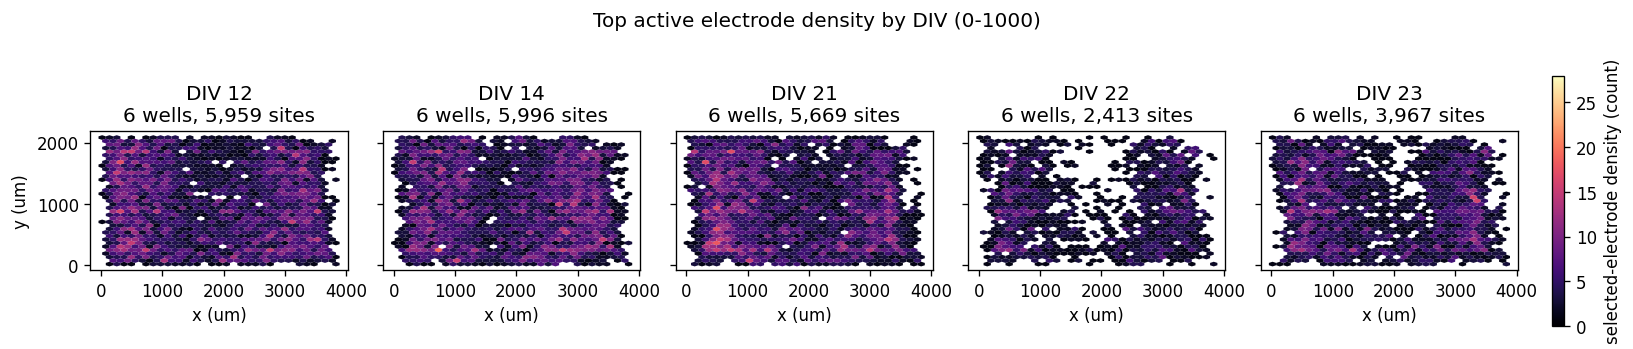

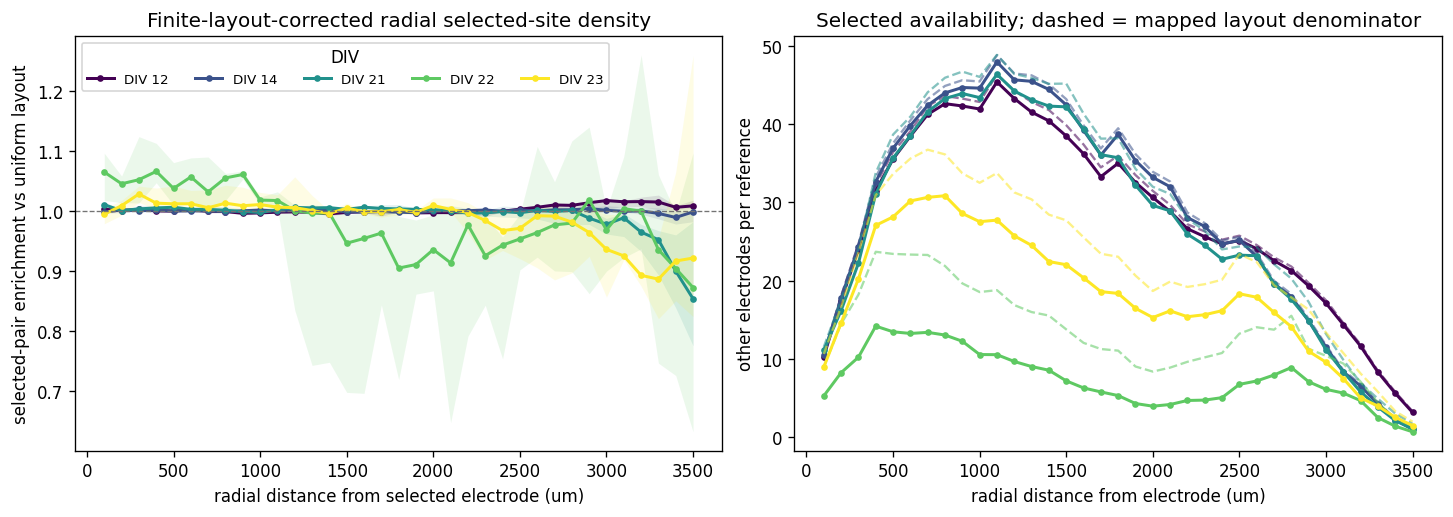

,div,n_recordings,median_selected_electrodes,median_anisotropy_ratio,median_x_extent_um,median_y_extent_um
0,12,6,996.0,1.90,3780.0,2065.0
1,14,6,1000.0,1.78,3762.5,2065.0
2,21,6,958.5,1.83,3710.0,2065.0
3,22,6,282.5,2.14,3605.0,2030.0
4,23,6,671.5,1.91,3710.0,2065.0


In [68]:
density_items = all_activity_results if "all_activity_results" in globals() else activity_results
selected_electrode_rows = []
for item in density_items:
    spec = item["spec"]
    rec = item["recording"]
    coords = electrode_coords_um(rec.layout)
    refs = np.asarray([int(e) for e in item.get("refs", []) if int(e) in coords.index], dtype=int)
    if refs.size == 0:
        continue
    ref_coords = coords.loc[refs].reset_index().rename(columns={"index": "electrode"})
    for row in ref_coords.itertuples(index=False):
        selected_electrode_rows.append({
            "dataset": spec["dataset"],
            "well": int(spec["well"]),
            "div": int(spec.get("div", DIV)),
            "recording_id": spec["recording_id"],
            "electrode": int(row.electrode),
            "x_um": float(row.x),
            "y_um": float(row.y),
        })
selected_electrode_df = pd.DataFrame(selected_electrode_rows)
if selected_electrode_df.empty:
    raise ValueError("No selected electrode coordinates were available for density progression plots.")

# Simple anisotropy proxy: covariance eigenvalue ratio of selected-electrode positions per recording.
anisotropy_rows = []
for (div, well, recording_id), group in selected_electrode_df.groupby(["div", "well", "recording_id"]):
    xy = group[["x_um", "y_um"]].to_numpy(float)
    if xy.shape[0] < 3:
        ratio = np.nan
        orientation_rad = np.nan
    else:
        centered = xy - np.nanmean(xy, axis=0, keepdims=True)
        cov = np.cov(centered.T)
        evals, evecs = np.linalg.eigh(cov)
        order = np.argsort(evals)[::-1]
        evals = evals[order]
        evecs = evecs[:, order]
        ratio = float(np.sqrt(evals[0] / max(evals[-1], np.finfo(float).eps)))
        orientation_rad = float(np.arctan2(evecs[1, 0], evecs[0, 0]))
    anisotropy_rows.append({
        "div": int(div),
        "well": int(well),
        "recording_id": recording_id,
        "n_selected_electrodes": int(xy.shape[0]),
        "x_extent_um": float(np.nanmax(xy[:, 0]) - np.nanmin(xy[:, 0])),
        "y_extent_um": float(np.nanmax(xy[:, 1]) - np.nanmin(xy[:, 1])),
        "anisotropy_ratio": ratio,
        "anisotropy_orientation_rad": orientation_rad,
    })
selected_density_summary = pd.DataFrame(anisotropy_rows)

density_divs = list(AGGREGATE_DIVS) if "AGGREGATE_DIVS" in globals() else sorted(selected_electrode_df["div"].unique())
density_divs = [int(d) for d in density_divs]
xmin, xmax = selected_electrode_df["x_um"].min(), selected_electrode_df["x_um"].max()
ymin, ymax = selected_electrode_df["y_um"].min(), selected_electrode_df["y_um"].max()
extent = (xmin, xmax, ymin, ymax)

# Use a shared color scale across DIVs so progression is visually comparable.
hex_counts = []
for div in density_divs:
    df = selected_electrode_df[selected_electrode_df["div"] == div]
    if df.empty:
        continue
    counts, _, _ = np.histogram2d(df["x_um"], df["y_um"], bins=[32, 20], range=[[xmin, xmax], [ymin, ymax]])
    hex_counts.append(counts.max())
density_vmax = max(hex_counts) if hex_counts else 1.0

fig, axes = plt.subplots(1, len(density_divs), figsize=(2.7 * len(density_divs), 3.0), sharex=True, sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
last_hb = None
for ax, div in zip(axes, density_divs):
    df = selected_electrode_df[selected_electrode_df["div"] == div]
    ax.set_aspect("equal", adjustable="box")
    if df.empty:
        ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", color="0.55")
        ax.set_title(f"DIV {div}")
        continue
    last_hb = ax.hexbin(
        df["x_um"], df["y_um"], gridsize=32, extent=extent, mincnt=1,
        cmap="magma", vmin=0, vmax=density_vmax, linewidths=0.0,
    )
    n_wells = df["well"].nunique()
    ax.set_title(f"DIV {div}\n{n_wells} wells, {len(df):,} sites")
    ax.set_xlabel("x (um)")
axes[0].set_ylabel("y (um)")
if last_hb is not None:
    cbar = fig.colorbar(last_hb, ax=axes.ravel().tolist(), shrink=0.78, pad=0.01)
    cbar.set_label("selected-electrode density (count)")
fig.suptitle(f"Top active electrode density by DIV ({TOP_START}-{TOP_STOP})")
plt.show()

# Distance-bin availability corrected by the empirical finite HD-MEA layout.
# Numerator: directed selected-electrode pairs per radial bin.
# Denominator: directed pairs available among all mapped electrodes in the same recording.
# This corrects for rectangular-array edges and missing layout positions without slow per-pair circle sampling.
pair_count_rows = []
edges, centers = distance_edges_and_centers()
for item in density_items:
    spec = item["spec"]
    rec = item["recording"]
    coords = electrode_coords_um(rec.layout)
    refs = np.asarray([int(e) for e in item.get("refs", []) if int(e) in coords.index], dtype=int)

    selected_electrodes, _sel_ref_idx, _sel_target_idx, _sel_distance_um, selected_bin_idx, bin_centers = build_pair_arrays(refs, coords)
    mapped_electrodes = np.asarray(coords.index.to_numpy(dtype=int), dtype=int)
    all_electrodes, _all_ref_idx, _all_target_idx, _all_distance_um, all_bin_idx, all_bin_centers = build_pair_arrays(mapped_electrodes, coords)
    if all_electrodes.size < 2 or all_bin_idx.size == 0:
        continue

    n_bins = len(all_bin_centers)
    selected_counts = np.bincount(selected_bin_idx, minlength=n_bins).astype(float) if selected_bin_idx.size else np.zeros(n_bins, dtype=float)
    all_counts = np.bincount(all_bin_idx, minlength=n_bins).astype(float)
    selected_fraction = np.divide(
        selected_counts,
        all_counts,
        out=np.full(n_bins, np.nan, dtype=float),
        where=all_counts > 0,
    )
    selected_other_per_ref = np.divide(
        selected_counts,
        max(1, selected_electrodes.size),
        out=np.zeros(n_bins, dtype=float),
    )
    available_mapped_other_per_ref = np.divide(
        all_counts,
        max(1, all_electrodes.size),
        out=np.zeros(n_bins, dtype=float),
    )
    if all_electrodes.size > 1:
        finite_selection_pair_fraction = (selected_electrodes.size * max(0, selected_electrodes.size - 1)) / (all_electrodes.size * (all_electrodes.size - 1))
    else:
        finite_selection_pair_fraction = np.nan
    expected_selected_pairs_if_uniform = all_counts * finite_selection_pair_fraction
    enrichment_vs_uniform_selection = np.divide(
        selected_counts,
        expected_selected_pairs_if_uniform,
        out=np.full(n_bins, np.nan, dtype=float),
        where=expected_selected_pairs_if_uniform > 0,
    )

    for idx, center in enumerate(all_bin_centers):
        pair_count_rows.append({
            "dataset": spec["dataset"],
            "well": int(spec["well"]),
            "div": int(spec.get("div", DIV)),
            "recording_id": spec["recording_id"],
            "distance_bin_idx": int(idx),
            "distance_bin_center_um": float(center),
            "selected_directed_pair_count": int(selected_counts[idx]),
            "available_mapped_directed_pair_count": int(all_counts[idx]),
            "other_selected_electrodes_per_ref": float(selected_other_per_ref[idx]),
            "available_mapped_electrodes_per_ref": float(available_mapped_other_per_ref[idx]),
            "selected_fraction_of_available_pairs": float(selected_fraction[idx]),
            "enrichment_vs_uniform_selection": float(enrichment_vs_uniform_selection[idx]),
            "n_selected_electrodes": int(selected_electrodes.size),
            "n_mapped_electrodes": int(all_electrodes.size),
        })
selected_pair_density_df = pd.DataFrame(pair_count_rows)
selected_pair_density_summary = (
    selected_pair_density_df
    .groupby(["div", "distance_bin_center_um"], as_index=False)
    .agg(
        selected_fraction_median=("selected_fraction_of_available_pairs", "median"),
        selected_fraction_low=("selected_fraction_of_available_pairs", lambda x: np.nanquantile(x, 0.25)),
        selected_fraction_high=("selected_fraction_of_available_pairs", lambda x: np.nanquantile(x, 0.75)),
        enrichment_median=("enrichment_vs_uniform_selection", "median"),
        enrichment_low=("enrichment_vs_uniform_selection", lambda x: np.nanquantile(x, 0.25)),
        enrichment_high=("enrichment_vs_uniform_selection", lambda x: np.nanquantile(x, 0.75)),
        available_mapped_per_ref_median=("available_mapped_electrodes_per_ref", "median"),
        other_selected_per_ref_median=("other_selected_electrodes_per_ref", "median"),
        n_wells=("well", "nunique"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), constrained_layout=True)
cmap = plt.get_cmap("viridis")
colors = {div: cmap(i / max(1, len(density_divs) - 1)) for i, div in enumerate(density_divs)}
for div in density_divs:
    df = selected_pair_density_summary[selected_pair_density_summary["div"] == div].sort_values("distance_bin_center_um")
    if df.empty:
        continue
    x = df["distance_bin_center_um"].to_numpy(float)
    y = df["enrichment_median"].to_numpy(float)
    lo = df["enrichment_low"].to_numpy(float)
    hi = df["enrichment_high"].to_numpy(float)
    axes[0].fill_between(x, lo, hi, color=colors[div], alpha=0.12, lw=0)
    axes[0].plot(x, y, color=colors[div], lw=1.8, marker="o", ms=3, label=f"DIV {div}")
    axes[1].plot(x, df["available_mapped_per_ref_median"].to_numpy(float), color=colors[div], lw=1.4, ls="--", alpha=0.55)
    axes[1].plot(x, df["other_selected_per_ref_median"].to_numpy(float), color=colors[div], lw=1.8, marker="o", ms=3, label=f"DIV {div}")
axes[0].axhline(1.0, color="0.45", lw=0.8, ls="--")
axes[0].set_xlabel("radial distance from selected electrode (um)")
axes[0].set_ylabel("selected-pair enrichment vs uniform layout")
axes[0].set_title("Finite-layout-corrected radial selected-site density")
axes[0].legend(title="DIV", ncol=min(5, len(density_divs)), fontsize=8)
axes[1].set_xlabel("radial distance from electrode (um)")
axes[1].set_ylabel("other electrodes per reference")
axes[1].set_title("Selected availability; dashed = mapped layout denominator")
plt.show()


display(selected_density_summary.groupby("div", as_index=False).agg(
    n_recordings=("recording_id", "nunique"),
    median_selected_electrodes=("n_selected_electrodes", "median"),
    median_anisotropy_ratio=("anisotropy_ratio", "median"),
    median_x_extent_um=("x_extent_um", "median"),
    median_y_extent_um=("y_extent_um", "median"),
).round(2))


## Pair-Sampling Diagnostics

Before running the bootstrap, check whether each distance bin is actually represented. Random ref/target sampling can make near-distance bins sparse on HD-MEA layouts; the default distance-stratified sampler should give balanced sampled pairs per bin.


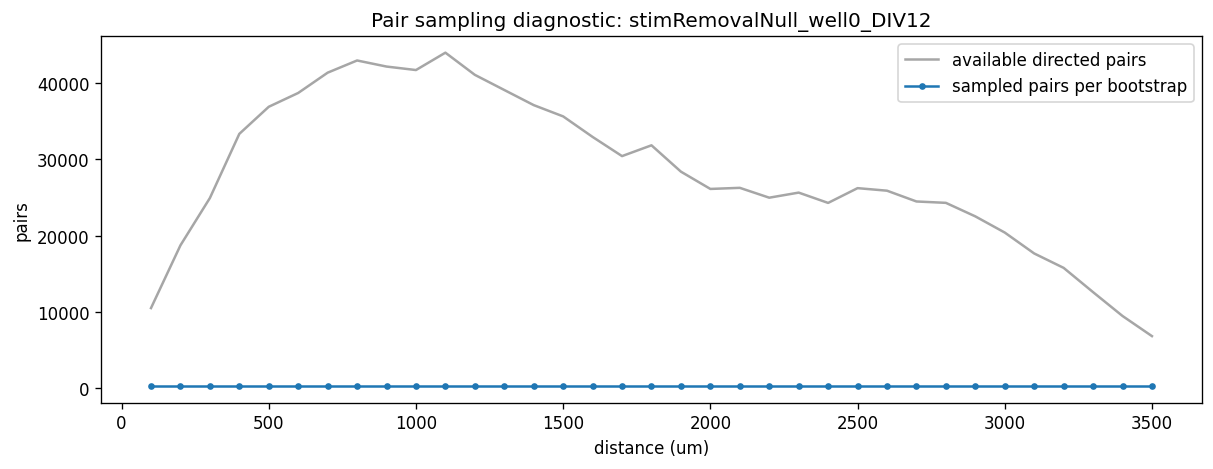

,distance_bin_center_um,available_directed_pairs,sampled_directed_pairs
0,100.0,10484,250
1,200.0,18724,250
2,300.0,24936,250
3,400.0,33362,250
4,500.0,36920,250
5,600.0,38734,250
6,700.0,41398,250
7,800.0,43000,250
8,900.0,42202,250
9,1000.0,41744,250


In [69]:
diagnostic_item = activity_results[0]
diagnostic_coords = electrode_coords_um(diagnostic_item["recording"].layout)
diagnostic_available = np.asarray([e for e in diagnostic_item["refs"] if int(e) in diagnostic_coords.index], dtype=int)
diagnostic_pair_catalog = build_pair_catalog(diagnostic_available, diagnostic_coords)

rng = np.random.default_rng(int(SYNC_RANDOM_SEED))
sampled_parts = []
if diagnostic_pair_catalog.empty:
    diagnostic_sampled_pairs = diagnostic_pair_catalog.copy()
elif SYNC_PAIR_SAMPLING == "distance_stratified":
    for _, group in diagnostic_pair_catalog.groupby("distance_bin_idx", sort=True):
        n_keep = min(int(SYNC_PAIRS_PER_DISTANCE_BIN), len(group))
        if n_keep <= 0:
            continue
        sampled_parts.append(group.iloc[rng.choice(len(group), size=n_keep, replace=False)])
    diagnostic_sampled_pairs = pd.concat(sampled_parts, ignore_index=True) if sampled_parts else diagnostic_pair_catalog.iloc[:0].copy()
elif SYNC_PAIR_SAMPLING == "random_ref_target":
    n_refs = min(int(SYNC_N_REF_ELECTRODES), diagnostic_available.size)
    ref_electrodes = rng.choice(diagnostic_available, size=n_refs, replace=False) if n_refs else np.array([], dtype=int)
    n_targets = min(int(SYNC_N_TARGET_ELECTRODES), diagnostic_available.size)
    target_electrodes = rng.choice(diagnostic_available, size=n_targets, replace=False) if n_targets else np.array([], dtype=int)
    diagnostic_sampled_pairs = diagnostic_pair_catalog[
        diagnostic_pair_catalog["ref_electrode"].isin(ref_electrodes)
        & diagnostic_pair_catalog["target_electrode"].isin(target_electrodes)
        & (diagnostic_pair_catalog["ref_electrode"] != diagnostic_pair_catalog["target_electrode"])
    ].copy()
else:
    raise ValueError("SYNC_PAIR_SAMPLING must be 'distance_stratified' or 'random_ref_target'.")

catalog_counts = (
    diagnostic_pair_catalog
    .groupby("distance_bin_center_um", as_index=False)
    .size()
    .rename(columns={"size": "available_directed_pairs"})
)
sampled_counts = (
    diagnostic_sampled_pairs
    .groupby("distance_bin_center_um", as_index=False)
    .size()
    .rename(columns={"size": "sampled_directed_pairs"})
)
pair_sampling_diagnostic = catalog_counts.merge(sampled_counts, on="distance_bin_center_um", how="left").fillna({"sampled_directed_pairs": 0})

fig, ax = plt.subplots(figsize=(10, 3.8), constrained_layout=True)
ax.plot(pair_sampling_diagnostic["distance_bin_center_um"], pair_sampling_diagnostic["available_directed_pairs"], color="0.65", label="available directed pairs")
ax.plot(pair_sampling_diagnostic["distance_bin_center_um"], pair_sampling_diagnostic["sampled_directed_pairs"], color="tab:blue", marker="o", ms=3, label="sampled pairs per bootstrap")
ax.set_xlabel("distance (um)")
ax.set_ylabel("pairs")
ax.set_title(f"Pair sampling diagnostic: {diagnostic_item['spec']['recording_id']}")
ax.legend(loc="best")
plt.show()

pair_sampling_diagnostic.head(12)


In [70]:
def synchrony_cache_settings():
    return {
        "DATASET": DATASET,
        "RUN_MODE": RUN_MODE,
        "wells": sorted(recording_spec_table["well"].astype(int).unique().tolist()),
        "divs": sorted(pd.Series(recording_spec_table["div"]).dropna().astype(int).unique().tolist()),
        "TEMPORAL_SUBSET": TEMPORAL_SUBSET,
        "SYNC_ACTIVITY_SCOPE": SYNC_ACTIVITY_SCOPE,
        "PRIMARY_LAG_WINDOW_MS": tuple(map(float, PRIMARY_LAG_WINDOW_MS)),
        "SYNC_LAG_WINDOWS_MS": [tuple(map(float, w)) for w in SYNC_LAG_WINDOWS_MS],
        "SYNC_EVALUATE_DIRECTED_LAG_WINDOWS": bool(SYNC_EVALUATE_DIRECTED_LAG_WINDOWS),
        "DISTANCE_BIN_UM": float(DISTANCE_BIN_UM),
        "MIN_DISTANCE_UM": float(MIN_DISTANCE_UM),
        "MAX_DISTANCE_UM": float(MAX_DISTANCE_UM),
        "SYNC_COMPUTE_METHOD": SYNC_COMPUTE_METHOD,
        "SYNC_ESTIMATOR_VERSION": "interval_summary_v1",
        "SYNC_MATRIX_BIN_MS": float(SYNC_MATRIX_BIN_MS),
        "SYNC_NULL_METHOD": SYNC_NULL_METHOD,
        "SYNC_JITTER_MS": float(SYNC_JITTER_MS),
        "SYNC_BOOTSTRAP_REPS": int(SYNC_BOOTSTRAP_REPS),
        "SYNC_N_SURROGATES": int(SYNC_N_SURROGATES),
        "SYNC_PAIR_SAMPLING": SYNC_PAIR_SAMPLING,
        "SYNC_PAIRS_PER_DISTANCE_BIN": int(SYNC_PAIRS_PER_DISTANCE_BIN),
        "SYNC_N_REF_ELECTRODES": int(SYNC_N_REF_ELECTRODES),
        "SYNC_N_TARGET_ELECTRODES": int(SYNC_N_TARGET_ELECTRODES),
        "SYNC_MIN_TRIGGER_SPIKES": int(SYNC_MIN_TRIGGER_SPIKES),
        "SYNC_NULL_STD_FLOOR": float(SYNC_NULL_STD_FLOOR),
        "SYNC_RANDOM_SEED": int(SYNC_RANDOM_SEED),
        "SMOKE_MODE": bool(SMOKE_MODE),
    }


def cache_path_for_settings():
    settings = synchrony_cache_settings()
    digest = hashlib.sha1(json.dumps(settings, sort_keys=True).encode("utf-8")).hexdigest()[:12]
    wells = "-".join(map(str, settings["wells"]))
    divs = "-".join(map(str, settings["divs"])) or "na"
    mode_tag = "smoke" if SMOKE_MODE else "full"
    name = f"sync_{DATASET}_{RUN_MODE}_w{wells}_d{divs}_{TEMPORAL_SUBSET}_{SYNC_NULL_METHOD}_{mode_tag}_{digest}.pkl"
    return OUTPUT_ROOT / name


cache_path = cache_path_for_settings()
cache_path.parent.mkdir(parents=True, exist_ok=True)

if cache_path.exists() and not FORCE_RECOMPUTE:
    with cache_path.open("rb") as f:
        cached = pickle.load(f)
    recording_summary = cached["recording_summary"]
    interval_summary = cached["interval_summary"]
    pair_sync_samples = cached["pair_sync_samples"]
    print(f"Loaded cached synchrony result: {cache_path}")
else:
    rng = np.random.default_rng(int(SYNC_RANDOM_SEED))
    chunks = []
    for item in activity_results:
        print(f"Processing {item['spec']['recording_id']} with {len(item['selected_intervals'])} selected intervals")
        chunk = bootstrap_recording_synchrony(item, rng=rng)
        if not chunk.empty:
            chunks.append(chunk)
    pair_sync_samples = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
    cache_settings = synchrony_cache_settings()
    with cache_path.open("wb") as f:
        pickle.dump(
            {
                "recording_summary": recording_summary,
                "interval_summary": interval_summary,
                "pair_sync_samples": pair_sync_samples,
                "settings": cache_settings,
            },
            f,
        )
    print(f"Saved synchrony result cache: {cache_path}")

if pair_sync_samples.empty:
    raise ValueError("No synchrony samples were produced. Check selected intervals, electrode selection, and bootstrap settings.")

pair_sync_samples.head()


Loaded cached synchrony result: /Users/danielrebbin/Documents/GitHub/ephax/outputs/activity_distance/sync_stim_removal_null_div_progression_w0-1-2-3-4-5_d12-14-21-22-23_burst_interval_jitter_smoke_978d6976ba49.pkl


,dataset,well,div,recording_id,activity_scope,bootstrap_idx,compute_method,null_method,lag_start_ms,lag_stop_ms,distance_bin_idx,distance_bin_center_um,n_pairs,n_trigger_spikes,p_obs,p_null_mean,excess_sync,z_sync,log_ratio,p_obs_median,p_null_mean_median,excess_sync_median,z_sync_median,log_ratio_median
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,0,interval_summary_matrix,interval_jitter,-2.0,2.0,0,100.0,229189,397701,0.071361,0.051654,0.019707,-0.029387,-0.014737,0.0,0.0,0.0,-0.5,0.0
1,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,0,interval_summary_matrix,interval_jitter,-2.0,2.0,1,200.0,411010,716592,0.071006,0.051634,0.019373,-0.039367,-0.016242,0.0,0.0,0.0,-0.5,0.0
2,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,0,interval_summary_matrix,interval_jitter,-2.0,2.0,2,300.0,537038,933638,0.069494,0.050564,0.018931,-0.040446,-0.015442,0.0,0.0,0.0,-0.5,0.0
3,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,0,interval_summary_matrix,interval_jitter,-2.0,2.0,3,400.0,715392,1240013,0.066504,0.049503,0.017002,-0.054418,-0.018721,0.0,0.0,0.0,-0.5,0.0
4,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,0,interval_summary_matrix,interval_jitter,-2.0,2.0,4,500.0,779374,1344852,0.064035,0.048280,0.015754,-0.062948,-0.019725,0.0,0.0,0.0,-0.5,0.0


## Validation and Distance-Binned Summaries

In [71]:
if "distance_um" in pair_sync_samples.columns:
    pair_sync_samples = add_distance_bins(pair_sync_samples)
else:
    pair_sync_samples = pair_sync_samples.copy()

assert pair_sync_samples["p_obs"].between(0, 1).all(), "p_obs outside [0, 1]"
assert pair_sync_samples["p_null_mean"].between(0, 1).all(), "p_null_mean outside [0, 1]"
assert pair_sync_samples["excess_sync"].between(-1, 1).all(), "excess_sync outside [-1, 1]"
if {"ref_electrode", "target_electrode"}.issubset(pair_sync_samples.columns):
    assert not (pair_sync_samples["ref_electrode"] == pair_sync_samples["target_electrode"]).any(), "self-pairs were not excluded"
if "distance_um" in pair_sync_samples.columns:
    assert pair_sync_samples["distance_um"].between(MIN_DISTANCE_UM, MAX_DISTANCE_UM).all(), "distance outside configured range"

print(f"Synchrony rows: {len(pair_sync_samples):,}")
print(f"Unique recording ids: {pair_sync_samples['recording_id'].nunique()}")
print(f"Unique lag windows: {pair_sync_samples[['lag_start_ms', 'lag_stop_ms']].drop_duplicates().shape[0]}")
print("Compute method:", pair_sync_samples.get("compute_method", pd.Series(["pair_loop"])).iloc[0])
pair_sync_samples[["p_obs", "p_null_mean", "excess_sync", "z_sync", "log_ratio"]].describe()

Synchrony rows: 15,750
Unique recording ids: 30
Unique lag windows: 3
Compute method: interval_summary_matrix


,p_obs,p_null_mean,excess_sync,z_sync,log_ratio
count,15750.000000,15750.000000,15750.000000,15750.000000,15750.000000
mean,0.133950,0.098318,0.035633,-0.015560,-0.021199
std,0.052715,0.028063,0.033376,0.137567,0.054175
min,0.043422,0.040570,-0.048678,-0.501076,-0.197888
25%,0.090613,0.077123,0.010546,-0.109486,-0.056551
50%,0.130025,0.099947,0.022922,-0.052141,-0.032036
75%,0.165863,0.119805,0.055641,0.076078,0.011253
max,0.325926,0.191102,0.159720,0.557254,0.192779


In [72]:
def bootstrap_ci(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return pd.Series({"ci_low": np.nan, "ci_high": np.nan})
    return pd.Series({"ci_low": float(np.quantile(values, 0.025)), "ci_high": float(np.quantile(values, 0.975))})


if "compute_method" in pair_sync_samples.columns and pair_sync_samples["compute_method"].isin(["matrix", "interval_summary_matrix"]).all():
    # Matrix-style output is already one row per recording/bootstrap/distance bin/window.
    per_bootstrap_bin = pair_sync_samples.copy()
else:
    # Pair-loop fallback: first average pairs inside each bootstrap/distance bin.
    per_bootstrap_bin = (
        pair_sync_samples
        .groupby(
            [
                "dataset", "well", "div", "recording_id", "activity_scope",
                "lag_start_ms", "lag_stop_ms", "bootstrap_idx", "distance_bin_center_um",
            ],
            dropna=False,
        )
        .agg(
            n_pairs=("distance_um", "size"),
            n_trigger_spikes=("n_trigger_spikes", "sum"),
            p_obs=("p_obs", "mean"),
            p_null_mean=("p_null_mean", "mean"),
            excess_sync=("excess_sync", "mean"),
            z_sync=("z_sync", "mean"),
            log_ratio=("log_ratio", "mean"),
        )
        .reset_index()
    )

per_bootstrap_bin = per_bootstrap_bin[per_bootstrap_bin["n_pairs"] >= MIN_PAIRS_PER_DISTANCE_BIN].copy()
summary_groups = [
    "dataset", "well", "div", "recording_id", "activity_scope",
    "lag_start_ms", "lag_stop_ms", "distance_bin_center_um",
]

def _sem(x):
    x = np.asarray(x, dtype=float)
    n = np.count_nonzero(np.isfinite(x))
    return float(np.nanstd(x, ddof=1) / np.sqrt(n)) if n > 1 else np.nan

distance_bin_summary = (
    per_bootstrap_bin
    .groupby(summary_groups, dropna=False)
    .agg(
        n_bootstraps=("bootstrap_idx", "nunique"),
        n_pairs_median=("n_pairs", "median"),
        p_obs_mean=("p_obs", "mean"),
        p_obs_median=("p_obs", "median"),
        p_obs_sem=("p_obs", _sem),
        p_null_mean=("p_null_mean", "mean"),
        excess_sync_mean=("excess_sync", "mean"),
        excess_sync_median=("excess_sync", "median"),
        z_sync_mean=("z_sync", "mean"),
        z_sync_median=("z_sync", "median"),
        log_ratio_mean=("log_ratio", "mean"),
        log_ratio_median=("log_ratio", "median"),
    )
    .reset_index()
)

ci_frames = []
for metric in ["p_obs", "excess_sync", "z_sync", "log_ratio"]:
    ci = per_bootstrap_bin.groupby(summary_groups, dropna=False)[metric].apply(bootstrap_ci).unstack().reset_index()
    ci = ci.rename(columns={"ci_low": f"{metric}_ci_low", "ci_high": f"{metric}_ci_high"})
    ci_frames.append(ci)
for ci in ci_frames:
    distance_bin_summary = distance_bin_summary.merge(ci, on=summary_groups, how="left")

primary_mask = (
    (distance_bin_summary["lag_start_ms"] == float(PRIMARY_LAG_WINDOW_MS[0]))
    & (distance_bin_summary["lag_stop_ms"] == float(PRIMARY_LAG_WINDOW_MS[1]))
)
primary_distance_summary = distance_bin_summary.loc[primary_mask].copy()

distance_bin_summary.head()


,dataset,well,div,recording_id,activity_scope,lag_start_ms,lag_stop_ms,distance_bin_center_um,n_bootstraps,n_pairs_median,p_obs_mean,p_obs_median,p_obs_sem,p_null_mean,excess_sync_mean,excess_sync_median,z_sync_mean,z_sync_median,log_ratio_mean,log_ratio_median,p_obs_ci_low,p_obs_ci_high,excess_sync_ci_low,excess_sync_ci_high,z_sync_ci_low,z_sync_ci_high,log_ratio_ci_low,log_ratio_ci_high
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,-2.0,2.0,100.0,5,235232.0,0.075110,0.075208,0.003123,0.053051,0.022059,0.021919,-0.011588,-0.011830,-0.011359,-0.011540,0.066114,0.082463,0.017566,0.026350,-0.038838,0.019137,-0.015665,-0.005926
1,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,-2.0,2.0,200.0,5,421469.0,0.074870,0.074942,0.003191,0.053039,0.021830,0.021642,-0.024879,-0.032205,-0.012851,-0.013371,0.065656,0.081760,0.017259,0.025637,-0.053176,0.002878,-0.017248,-0.008555
2,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,-2.0,2.0,300.0,5,551478.0,0.073430,0.074197,0.003315,0.052357,0.021073,0.021356,-0.029898,-0.033819,-0.013329,-0.013070,0.063615,0.080840,0.015859,0.025110,-0.062628,-0.003486,-0.019135,-0.008765
3,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,-2.0,2.0,400.0,5,734550.0,0.070347,0.070133,0.003146,0.051052,0.019296,0.018785,-0.037133,-0.043773,-0.015816,-0.016924,0.061417,0.077725,0.014854,0.023541,-0.062375,-0.010389,-0.020377,-0.010294
4,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,burst,-2.0,2.0,500.0,5,800727.0,0.068592,0.069589,0.003301,0.049990,0.018602,0.019210,-0.051642,-0.048577,-0.016198,-0.015442,0.059044,0.075905,0.013748,0.022580,-0.084154,-0.029294,-0.021118,-0.011642


## Distance Summary Plots

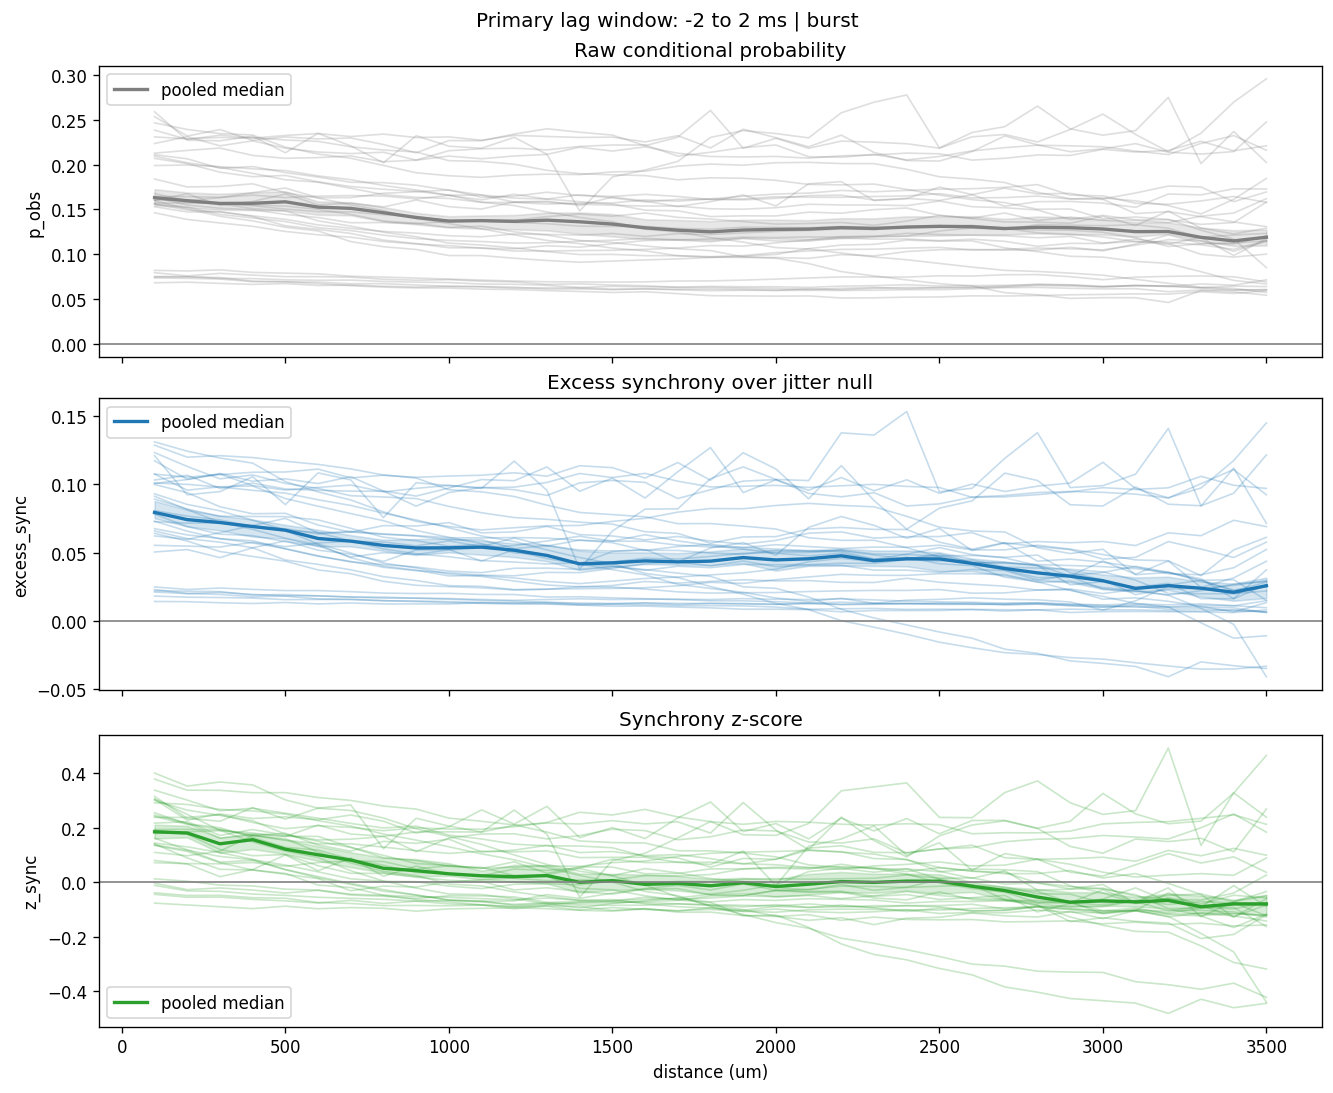

In [73]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, constrained_layout=True)
metrics = [
    ("p_obs", "Raw conditional probability", "tab:gray"),
    ("excess_sync", "Excess synchrony over jitter null", "tab:blue"),
    ("z_sync", "Synchrony z-score", "tab:green"),
]

for ax, (prefix, title, color) in zip(axes, metrics):
    for recording_id, df_i in primary_distance_summary.groupby("recording_id"):
        x = df_i["distance_bin_center_um"].to_numpy(dtype=float)
        y = df_i[f"{prefix}_median"].to_numpy(dtype=float) if f"{prefix}_median" in df_i else df_i[f"{prefix}_mean"].to_numpy(dtype=float)
        ax.plot(x, y, color=color, alpha=0.25, lw=1.0)

    pooled = (
        primary_distance_summary
        .groupby("distance_bin_center_um", as_index=False)
        .agg(
            median=(f"{prefix}_median" if f"{prefix}_median" in primary_distance_summary else f"{prefix}_mean", "median"),
            low=(f"{prefix}_ci_low", "median") if f"{prefix}_ci_low" in primary_distance_summary else (f"{prefix}_mean", "median"),
            high=(f"{prefix}_ci_high", "median") if f"{prefix}_ci_high" in primary_distance_summary else (f"{prefix}_mean", "median"),
        )
    )
    ax.plot(pooled["distance_bin_center_um"], pooled["median"], color=color, lw=2.0, label="pooled median")
    if "low" in pooled and "high" in pooled:
        ax.fill_between(pooled["distance_bin_center_um"], pooled["low"], pooled["high"], color=color, alpha=0.18)
    ax.axhline(0.0, color="0.5", lw=1.0)
    ax.set_ylabel(prefix)
    ax.set_title(title)
    ax.legend(loc="best")

axes[-1].set_xlabel("distance (um)")
fig.suptitle(f"Primary lag window: {PRIMARY_LAG_WINDOW_MS[0]:g} to {PRIMARY_LAG_WINDOW_MS[1]:g} ms | {SYNC_ACTIVITY_SCOPE}")
plt.show()

### Well x DIV excess synchrony grid

Primary-lag excess synchrony faceted by well and DIV. Rows are wells, columns are DIVs.


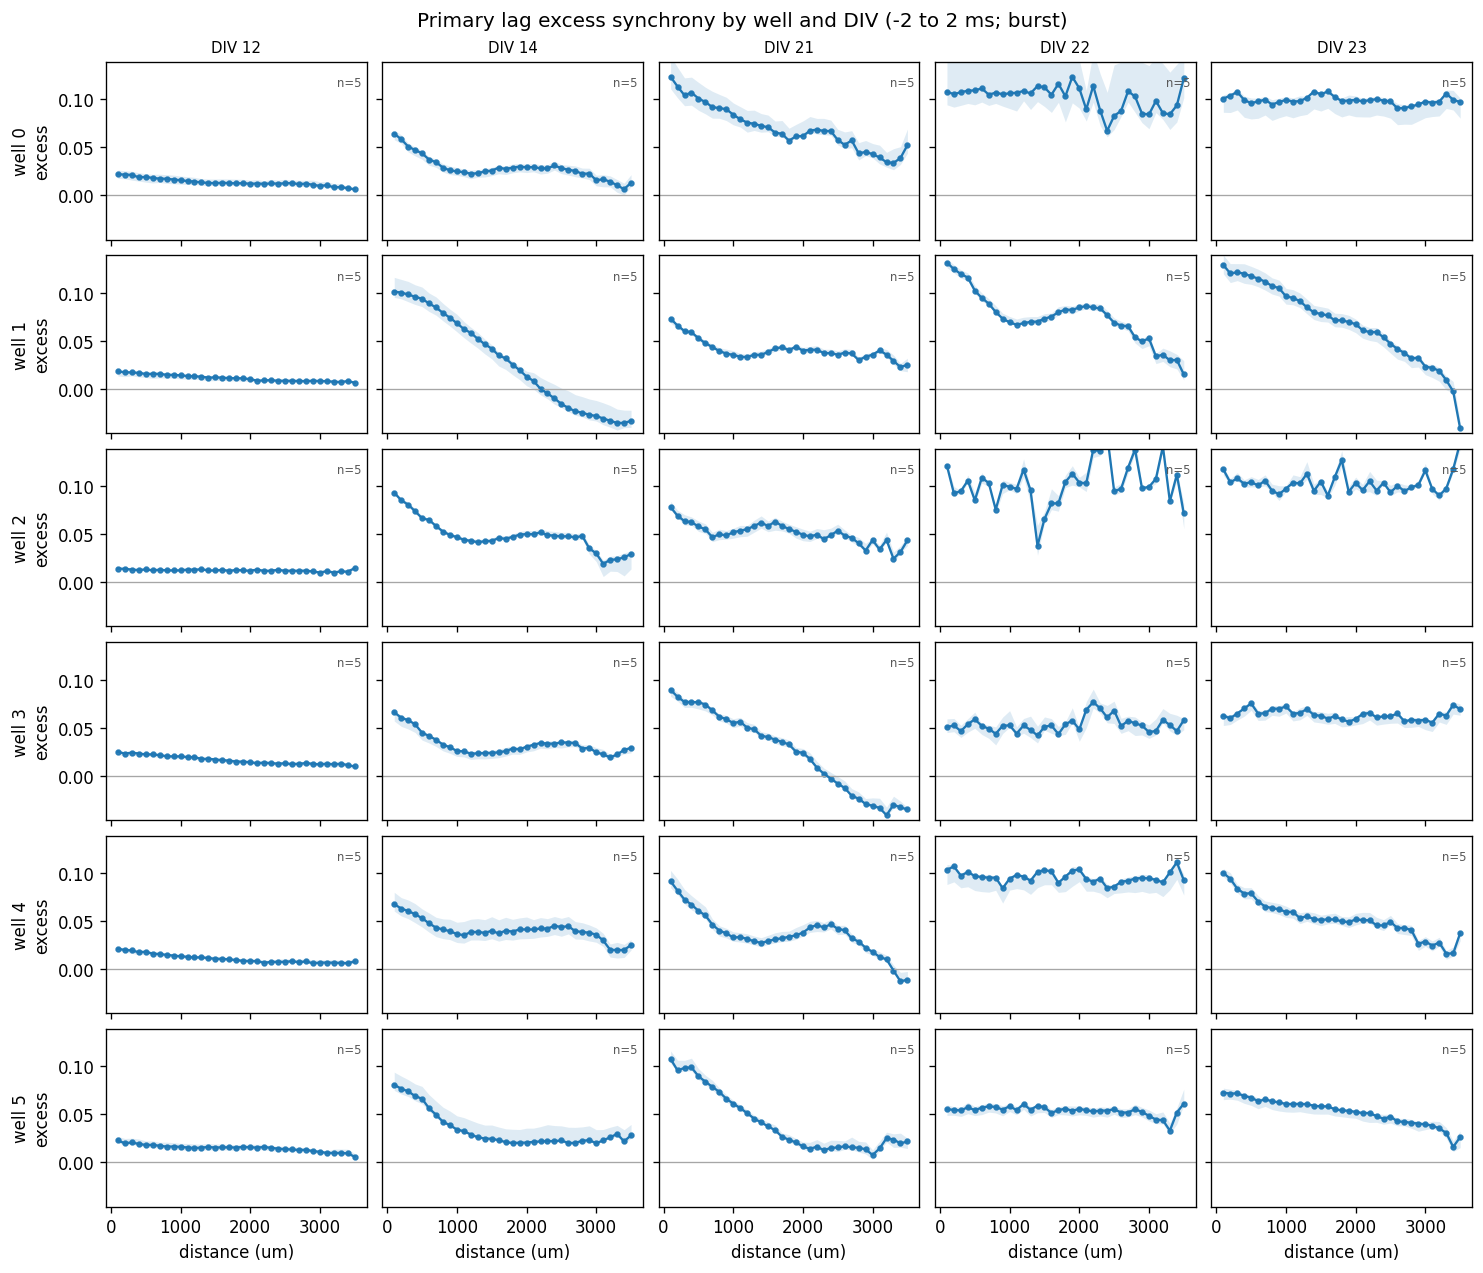

In [74]:
# 6 x 5 panel for DIV progression: rows are wells, columns are DIVs.
if primary_distance_summary.empty:
    print("No primary-distance synchrony summary is available.")
else:
    grid_wells = list(AGGREGATE_WELLS) if "AGGREGATE_WELLS" in globals() else sorted(primary_distance_summary["well"].dropna().astype(int).unique())
    grid_divs = list(AGGREGATE_DIVS) if "AGGREGATE_DIVS" in globals() else list(DIVS) if "DIVS" in globals() else sorted(primary_distance_summary["div"].dropna().astype(int).unique())
    grid_wells = [int(w) for w in grid_wells]
    grid_divs = [int(d) for d in grid_divs]

    y_metric = "excess_sync_median" if "excess_sync_median" in primary_distance_summary.columns else "excess_sync_mean"
    low_metric = "excess_sync_ci_low" if "excess_sync_ci_low" in primary_distance_summary.columns else None
    high_metric = "excess_sync_ci_high" if "excess_sync_ci_high" in primary_distance_summary.columns else None

    y_values = primary_distance_summary[y_metric].to_numpy(float)
    y_values = y_values[np.isfinite(y_values)]
    if y_values.size:
        y_lo, y_hi = np.nanpercentile(y_values, [1, 99])
        y_pad = max(0.002, 0.1 * (y_hi - y_lo))
        y_lim = (min(0.0, y_lo - y_pad), max(0.0, y_hi + y_pad))
    else:
        y_lim = (-0.01, 0.01)

    fig, axes = plt.subplots(
        len(grid_wells),
        len(grid_divs),
        figsize=(2.45 * len(grid_divs), 1.75 * len(grid_wells)),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.asarray(axes)
    if axes.ndim == 1:
        axes = axes.reshape(len(grid_wells), len(grid_divs))

    for row_idx, well in enumerate(grid_wells):
        for col_idx, div in enumerate(grid_divs):
            ax = axes[row_idx, col_idx]
            df = primary_distance_summary[
                (primary_distance_summary["well"].astype(int) == int(well))
                & (primary_distance_summary["div"].astype(int) == int(div))
            ].sort_values("distance_bin_center_um")
            ax.axhline(0.0, color="0.65", lw=0.8)
            if df.empty:
                ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", color="0.55", fontsize=8)
            else:
                x = df["distance_bin_center_um"].to_numpy(float)
                y = df[y_metric].to_numpy(float)
                if low_metric and high_metric and low_metric in df and high_metric in df:
                    lo = df[low_metric].to_numpy(float)
                    hi = df[high_metric].to_numpy(float)
                    finite_ci = np.isfinite(x) & np.isfinite(lo) & np.isfinite(hi)
                    if np.any(finite_ci):
                        ax.fill_between(x[finite_ci], lo[finite_ci], hi[finite_ci], color="tab:blue", alpha=0.14, lw=0)
                ax.plot(x, y, color="tab:blue", lw=1.4)
                ax.scatter(x, y, color="tab:blue", s=8, alpha=0.9)
                n_boot = int(df["n_bootstraps"].median()) if "n_bootstraps" in df and df["n_bootstraps"].notna().any() else 0
                ax.text(0.98, 0.92, f"n={n_boot}", transform=ax.transAxes, ha="right", va="top", fontsize=7, color="0.35")
            ax.set_ylim(*y_lim)
            if row_idx == 0:
                ax.set_title(f"DIV {div}", fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(f"well {well}\nexcess")
            if row_idx == len(grid_wells) - 1:
                ax.set_xlabel("distance (um)")

    fig.suptitle(
        f"Primary lag excess synchrony by well and DIV ({PRIMARY_LAG_WINDOW_MS[0]:g} to {PRIMARY_LAG_WINDOW_MS[1]:g} ms; {SYNC_ACTIVITY_SCOPE})",
        fontsize=12,
    )
    plt.show()


### Aggregate excess synchrony by DIV

Across-well aggregate primary-lag excess synchrony for each DIV.


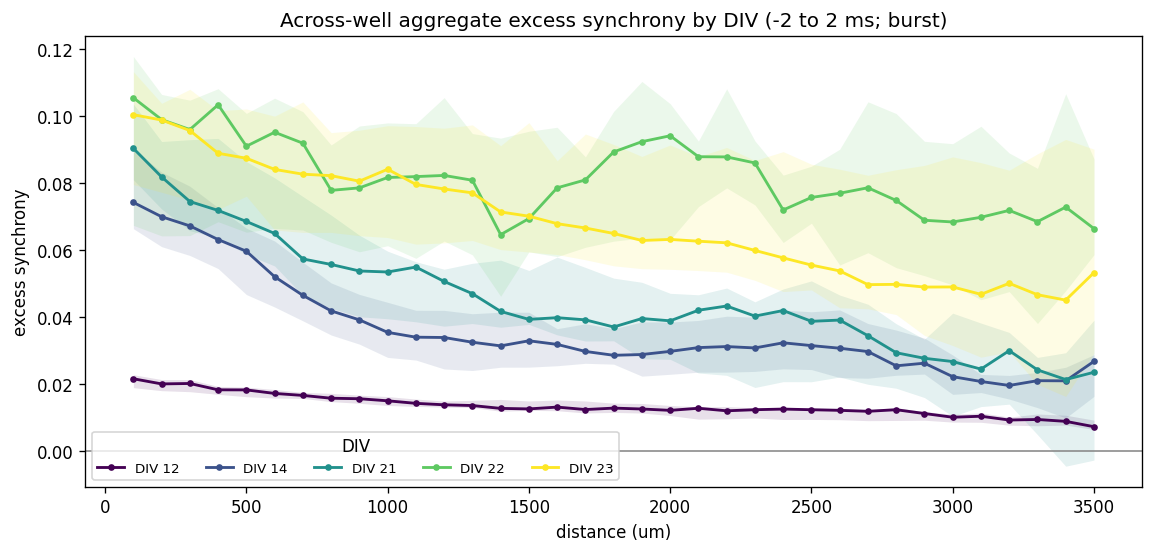

In [75]:
if primary_distance_summary.empty:
    print("No primary-distance synchrony summary is available.")
else:
    plot_divs = list(AGGREGATE_DIVS) if "AGGREGATE_DIVS" in globals() else list(DIVS) if "DIVS" in globals() else sorted(primary_distance_summary["div"].dropna().astype(int).unique())
    plot_divs = [int(d) for d in plot_divs]
    y_metric = "excess_sync_median" if "excess_sync_median" in primary_distance_summary.columns else "excess_sync_mean"

    div_aggregate_rows = []
    for (div, distance), group in primary_distance_summary.groupby(["div", "distance_bin_center_um"], dropna=False):
        values = group[y_metric].to_numpy(float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        div_aggregate_rows.append({
            "div": int(div),
            "distance_bin_center_um": float(distance),
            "excess_sync_median_across_wells": float(np.nanmedian(values)),
            "excess_sync_low_across_wells": float(np.nanquantile(values, 0.25)) if values.size > 1 else np.nan,
            "excess_sync_high_across_wells": float(np.nanquantile(values, 0.75)) if values.size > 1 else np.nan,
            "n_wells": int(values.size),
        })
    div_aggregate_summary = pd.DataFrame(div_aggregate_rows)

    fig, ax = plt.subplots(figsize=(9.5, 4.5), constrained_layout=True)
    cmap = plt.get_cmap("viridis")
    colors = {div: cmap(i / max(1, len(plot_divs) - 1)) for i, div in enumerate(plot_divs)}
    for div in plot_divs:
        df = div_aggregate_summary[div_aggregate_summary["div"] == int(div)].sort_values("distance_bin_center_um")
        if df.empty:
            continue
        x = df["distance_bin_center_um"].to_numpy(float)
        y = df["excess_sync_median_across_wells"].to_numpy(float)
        lo = df["excess_sync_low_across_wells"].to_numpy(float)
        hi = df["excess_sync_high_across_wells"].to_numpy(float)
        finite_band = np.isfinite(lo) & np.isfinite(hi)
        if np.any(finite_band):
            ax.fill_between(x[finite_band], lo[finite_band], hi[finite_band], color=colors[div], alpha=0.12, lw=0)
        ax.plot(x, y, marker="o", ms=3, lw=1.7, color=colors[div], label=f"DIV {div}")
    ax.axhline(0.0, color="0.55", lw=1.0)
    ax.set_xlabel("distance (um)")
    ax.set_ylabel("excess synchrony")
    ax.set_title(f"Across-well aggregate excess synchrony by DIV ({PRIMARY_LAG_WINDOW_MS[0]:g} to {PRIMARY_LAG_WINDOW_MS[1]:g} ms; {SYNC_ACTIVITY_SCOPE})")
    ax.legend(title="DIV", ncol=min(len(plot_divs), 5), fontsize=8)
    plt.show()

    div_aggregate_summary.head()


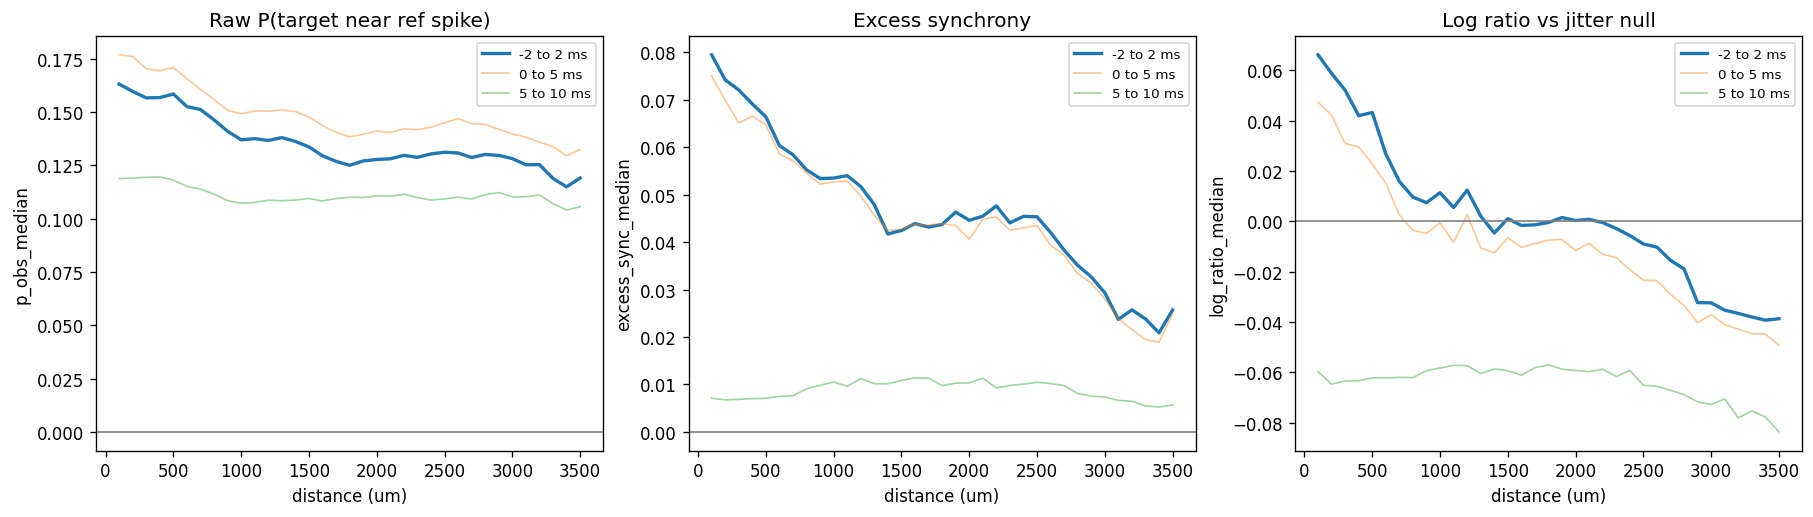

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
plot_metrics = [
    ("p_obs_median", "Raw P(target near ref spike)", "tab:gray"),
    ("excess_sync_median", "Excess synchrony", "tab:blue"),
    ("log_ratio_median", "Log ratio vs jitter null", "tab:purple"),
]
for ax, (metric, title, color) in zip(axes, plot_metrics):
    for (lag_start, lag_stop), df_lag in distance_bin_summary.groupby(["lag_start_ms", "lag_stop_ms"]):
        pooled = df_lag.groupby("distance_bin_center_um", as_index=False)[metric].median()
        alpha = 1.0 if (lag_start, lag_stop) == tuple(PRIMARY_LAG_WINDOW_MS) else 0.45
        lw = 2.0 if alpha == 1.0 else 1.0
        ax.plot(
            pooled["distance_bin_center_um"],
            pooled[metric],
            lw=lw,
            alpha=alpha,
            label=f"{lag_start:g} to {lag_stop:g} ms",
        )
    ax.axhline(0.0, color="0.5", lw=1.0)
    ax.set_title(title)
    ax.set_xlabel("distance (um)")
    ax.set_ylabel(metric)
    ax.legend(loc="best", fontsize=8)
plt.show()

## Nested Model Comparison: Axonal-Only vs Axonal-Ephaptic

Fit two nested models to all recording/bootstrap distance-bin rows for the primary lag window:

```text
axonal-only:     offset + amplitude * exp(-distance / axonal_decay_um)
axonal-ephaptic: offset + amplitude * exp(-distance / axonal_decay_um)
                  + coefficient * Figure1Correlation(distance, lambda_eph_um)
```

The oscillatory correlation-wave definition is the same one called by Figure 1: `45 Hz`, `v_eph=0.1 m/s`, and `v_ax=0.8 m/s`, giving a theoretical wavelength of `2539.68 um`. Unlike the Figure 1 visualization, this fit does not hold either attenuation length fixed. Both `axonal_decay_um` and `lambda_eph_um` are estimated from the synchrony data.

The classical nested F-test is reported as a descriptive model-comparison statistic. Because bootstrap curves are dependent resamples, and `lambda_eph_um` is not identifiable when the correlation coefficient is zero, cluster-bootstrap confidence intervals and the sign stability of the ephaptic coefficient are the primary uncertainty estimates.


In [77]:
def figure1_correlation_kernel(distance_um, lambda_eph_um):
    """Figure 1 correlation wave with a fitted spatial attenuation length."""
    return FIGURE1_WAVE_CONFIG.correlation_gain * correlation_function(
        np.asarray(distance_um, dtype=float),
        FIGURE1_WAVE_CONFIG.hz,
        FIGURE1_WAVE_CONFIG.v_eph_um_s,
        FIGURE1_WAVE_CONFIG.v_ax_um_s,
        float(lambda_eph_um),
    )


def axonal_only_model(distance_um, offset, amplitude, axonal_decay_um):
    distance_um = np.asarray(distance_um, dtype=float)
    return offset + amplitude * np.exp(-distance_um / axonal_decay_um)


def axonal_ephaptic_model(
    distance_um, offset, amplitude, axonal_decay_um, correlation_coefficient, lambda_eph_um
):
    return (
        axonal_only_model(distance_um, offset, amplitude, axonal_decay_um)
        + correlation_coefficient * figure1_correlation_kernel(distance_um, lambda_eph_um)
    )


def _information_criteria(rss, n_obs, n_params):
    rss = max(float(rss), np.finfo(float).tiny)
    return {
        "aic": float(n_obs * np.log(rss / n_obs) + 2 * n_params),
        "bic": float(n_obs * np.log(rss / n_obs) + n_params * np.log(n_obs)),
    }


def fit_nested_distance_models(rows):
    x = rows["distance_bin_center_um"].to_numpy(dtype=float)
    y = rows["excess_sync"].to_numpy(dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if x.size < 10:
        raise ValueError("Need at least ten finite distance-bin rows for nested model fitting.")

    offset0 = float(np.nanmedian(y[x >= np.nanquantile(x, 0.75)]))
    amplitude0 = float(max(np.nanmax(y) - offset0, 1e-6))
    axonal_params, _ = curve_fit(
        axonal_only_model,
        x,
        y,
        p0=[offset0, amplitude0, MODEL_INITIAL_AXONAL_DECAY_UM],
        bounds=([-np.inf, 0.0, 10.0], [np.inf, np.inf, 1e6]),
        maxfev=50000,
    )

    # lambda_eph_um and its coefficient interact nonlinearly. Use multiple starts
    # and retain the lowest-RSS converged fit rather than relying on one seed.
    coefficient_scale = float(max(np.ptp(y), 1e-6))
    ephaptic_candidates = []
    for lambda0 in [500.0, 1500.0, MODEL_INITIAL_LAMBDA_EPH_UM, 10000.0, 50000.0]:
        for coefficient0 in [-coefficient_scale, coefficient_scale]:
            try:
                params, _ = curve_fit(
                    axonal_ephaptic_model,
                    x,
                    y,
                    p0=[*axonal_params, coefficient0, lambda0],
                    bounds=([-np.inf, 0.0, 10.0, -np.inf, 50.0], [np.inf, np.inf, 1e6, np.inf, 1e6]),
                    maxfev=100000,
                )
            except Exception:
                continue
            residual = y - axonal_ephaptic_model(x, *params)
            ephaptic_candidates.append((float(np.sum(residual ** 2)), params))
    if not ephaptic_candidates:
        raise ValueError("No axonal-ephaptic model initialization converged.")
    _, ephaptic_params = min(ephaptic_candidates, key=lambda item: item[0])

    pred_axonal = axonal_only_model(x, *axonal_params)
    pred_ephaptic = axonal_ephaptic_model(x, *ephaptic_params)
    rss_axonal = float(np.sum((y - pred_axonal) ** 2))
    rss_ephaptic = float(np.sum((y - pred_ephaptic) ** 2))
    n_obs = int(x.size)
    df_num = len(ephaptic_params) - len(axonal_params)
    df_den = n_obs - len(ephaptic_params)
    improvement = max(0.0, rss_axonal - rss_ephaptic)
    f_stat = float((improvement / df_num) / (rss_ephaptic / df_den)) if df_den > 0 and rss_ephaptic > 0 else np.nan
    f_p_value = float(f_distribution.sf(f_stat, df_num, df_den)) if np.isfinite(f_stat) else np.nan
    tss = float(np.sum((y - np.mean(y)) ** 2))
    axonal_ic = _information_criteria(rss_axonal, n_obs, len(axonal_params))
    ephaptic_ic = _information_criteria(rss_ephaptic, n_obs, len(ephaptic_params))
    return {
        "n_obs": n_obs,
        "axonal_params": axonal_params,
        "ephaptic_params": ephaptic_params,
        "rss_axonal": rss_axonal,
        "rss_ephaptic": rss_ephaptic,
        "rss_improvement_fraction": float(improvement / rss_axonal) if rss_axonal > 0 else np.nan,
        "r2_axonal": float(1.0 - rss_axonal / tss) if tss > 0 else np.nan,
        "r2_ephaptic": float(1.0 - rss_ephaptic / tss) if tss > 0 else np.nan,
        "f_stat": f_stat,
        "f_p_value": f_p_value,
        "delta_aic_ephaptic_minus_axonal": float(ephaptic_ic["aic"] - axonal_ic["aic"]),
        "delta_bic_ephaptic_minus_axonal": float(ephaptic_ic["bic"] - axonal_ic["bic"]),
    }


def bootstrap_nested_distance_models(rows, distance_grid_um, n_reps=1000, seed=0):
    rows = rows.copy()
    rows["curve_id"] = rows["recording_id"].astype(str) + "::" + rows["bootstrap_idx"].astype(str)
    curve_ids = rows["curve_id"].drop_duplicates().to_numpy()
    if curve_ids.size == 0:
        raise ValueError("No recording/bootstrap curves available for model bootstrap.")
    grouped = {curve_id: rows.loc[rows["curve_id"] == curve_id] for curve_id in curve_ids}
    rng = np.random.default_rng(seed)
    metric_rows = []
    prediction_rows = []
    for bootstrap_idx in range(int(n_reps)):
        sampled_ids = rng.choice(curve_ids, size=curve_ids.size, replace=True)
        sampled = pd.concat([grouped[curve_id] for curve_id in sampled_ids], ignore_index=True)
        try:
            fit = fit_nested_distance_models(sampled)
        except Exception:
            continue
        metric_rows.append({
            "bootstrap_idx": bootstrap_idx,
            "axonal_offset": fit["axonal_params"][0],
            "axonal_amplitude": fit["axonal_params"][1],
            "axonal_decay_um": fit["axonal_params"][2],
            "ephaptic_offset": fit["ephaptic_params"][0],
            "ephaptic_amplitude": fit["ephaptic_params"][1],
            "ephaptic_axonal_decay_um": fit["ephaptic_params"][2],
            "correlation_coefficient": fit["ephaptic_params"][3],
            "lambda_eph_um": fit["ephaptic_params"][4],
            "rss_improvement_fraction": fit["rss_improvement_fraction"],
            "delta_aic_ephaptic_minus_axonal": fit["delta_aic_ephaptic_minus_axonal"],
            "delta_bic_ephaptic_minus_axonal": fit["delta_bic_ephaptic_minus_axonal"],
        })
        prediction_rows.append(pd.DataFrame({
            "bootstrap_idx": bootstrap_idx,
            "distance_um": distance_grid_um,
            "axonal_only": axonal_only_model(distance_grid_um, *fit["axonal_params"]),
            "axonal_ephaptic": axonal_ephaptic_model(distance_grid_um, *fit["ephaptic_params"]),
        }))
    return pd.DataFrame(metric_rows), pd.concat(prediction_rows, ignore_index=True) if prediction_rows else pd.DataFrame()


def percentile_interval(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    return tuple(float(v) for v in np.quantile(values, [0.5, 0.025, 0.975]))


primary_model_rows = per_bootstrap_bin.loc[
    (per_bootstrap_bin["lag_start_ms"] == float(PRIMARY_LAG_WINDOW_MS[0]))
    & (per_bootstrap_bin["lag_stop_ms"] == float(PRIMARY_LAG_WINDOW_MS[1]))
].copy()
primary_model_rows = primary_model_rows.dropna(subset=["distance_bin_center_um", "excess_sync"])
if primary_model_rows.empty:
    raise ValueError("No primary-lag distance-bin rows available for model fitting.")

full_data_model_fit = fit_nested_distance_models(primary_model_rows)
distance_grid_um = np.linspace(MIN_DISTANCE_UM, MAX_DISTANCE_UM, 400)
model_fit_bootstrap, model_prediction_bootstrap = bootstrap_nested_distance_models(
    primary_model_rows,
    distance_grid_um,
    n_reps=MODEL_FIT_BOOTSTRAP_REPS,
    seed=MODEL_FIT_RANDOM_SEED,
)
if model_fit_bootstrap.empty:
    raise ValueError("All nested-model bootstrap fits failed.")

model_prediction_summary = (
    model_prediction_bootstrap
    .groupby("distance_um", as_index=False)
    .agg(
        axonal_only_median=("axonal_only", "median"),
        axonal_only_ci_low=("axonal_only", lambda x: np.quantile(x, 0.025)),
        axonal_only_ci_high=("axonal_only", lambda x: np.quantile(x, 0.975)),
        axonal_ephaptic_median=("axonal_ephaptic", "median"),
        axonal_ephaptic_ci_low=("axonal_ephaptic", lambda x: np.quantile(x, 0.025)),
        axonal_ephaptic_ci_high=("axonal_ephaptic", lambda x: np.quantile(x, 0.975)),
    )
)

parameter_columns = [
    "axonal_offset", "axonal_amplitude", "axonal_decay_um",
    "ephaptic_offset", "ephaptic_amplitude", "ephaptic_axonal_decay_um",
    "correlation_coefficient", "lambda_eph_um", "rss_improvement_fraction",
    "delta_aic_ephaptic_minus_axonal", "delta_bic_ephaptic_minus_axonal",
]
model_parameter_summary = pd.DataFrame([
    {"parameter": column, "median": percentile_interval(model_fit_bootstrap[column])[0],
     "ci_low": percentile_interval(model_fit_bootstrap[column])[1],
     "ci_high": percentile_interval(model_fit_bootstrap[column])[2]}
    for column in parameter_columns
])
coefficient_values = model_fit_bootstrap["correlation_coefficient"].to_numpy(dtype=float)
bootstrap_two_sided_p = float(2.0 * min(np.mean(coefficient_values <= 0), np.mean(coefficient_values >= 0)))

model_fit_comparison = pd.DataFrame([{
    "n_distance_bin_rows": full_data_model_fit["n_obs"],
    "n_recording_bootstrap_curves": primary_model_rows[["recording_id", "bootstrap_idx"]].drop_duplicates().shape[0],
    "figure1_frequency_hz": FIGURE1_WAVE_CONFIG.hz,
    "figure1_wavelength_um": FIGURE1_WAVE_CONFIG.wavelength_um,
    "rss_axonal_only": full_data_model_fit["rss_axonal"],
    "rss_axonal_ephaptic": full_data_model_fit["rss_ephaptic"],
    "rss_improvement_fraction": full_data_model_fit["rss_improvement_fraction"],
    "r2_axonal_only": full_data_model_fit["r2_axonal"],
    "r2_axonal_ephaptic": full_data_model_fit["r2_ephaptic"],
    "fitted_axonal_decay_um_axonal_only": full_data_model_fit["axonal_params"][2],
    "fitted_axonal_decay_um_axonal_ephaptic": full_data_model_fit["ephaptic_params"][2],
    "fitted_lambda_eph_um": full_data_model_fit["ephaptic_params"][4],
    "nested_f_stat_descriptive": full_data_model_fit["f_stat"],
    "nested_f_p_value_descriptive": full_data_model_fit["f_p_value"],
    "bootstrap_two_sided_p_coefficient": bootstrap_two_sided_p,
    "delta_aic_ephaptic_minus_axonal": full_data_model_fit["delta_aic_ephaptic_minus_axonal"],
    "delta_bic_ephaptic_minus_axonal": full_data_model_fit["delta_bic_ephaptic_minus_axonal"],
    "successful_cluster_bootstrap_fits": len(model_fit_bootstrap),
}])

print(f"Figure 1 correlation wavelength: {FIGURE1_WAVE_CONFIG.wavelength_um:.2f} um")
print(f"Fitted axonal-only decay: {full_data_model_fit['axonal_params'][2]:.1f} um")
print(f"Fitted axonal-ephaptic decay: {full_data_model_fit['ephaptic_params'][2]:.1f} um")
print(f"Fitted ephaptic attenuation length: {full_data_model_fit['ephaptic_params'][4]:.1f} um")
print(f"Successful cluster bootstrap fits: {len(model_fit_bootstrap):,}/{MODEL_FIT_BOOTSTRAP_REPS:,}")
model_fit_comparison


KeyboardInterrupt: 

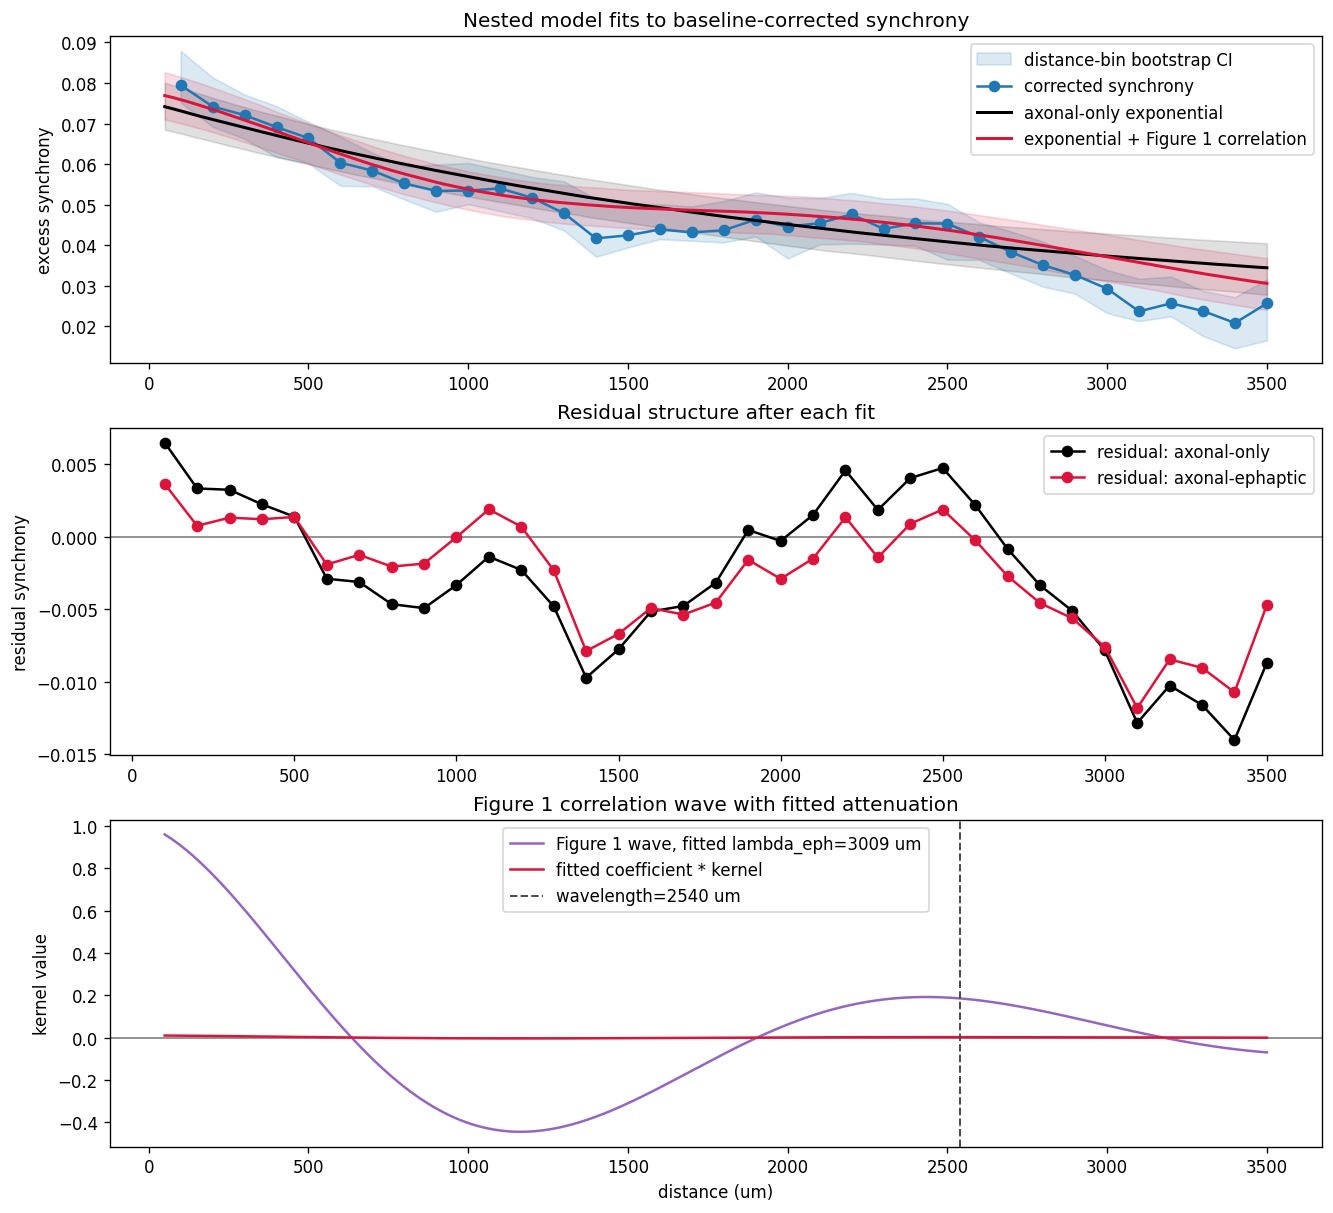

,parameter,median,ci_low,ci_high
0,axonal_offset,0.022943,0.002444,0.034721
1,axonal_amplitude,0.052756,0.040678,0.072660
2,axonal_decay_um,2292.088677,1568.067230,3616.692689
3,ephaptic_offset,-9.011668,-12.087096,-0.030464
4,ephaptic_amplitude,9.079758,0.101922,12.158584
5,ephaptic_axonal_decay_um,954391.655395,7586.204896,999999.999997
6,correlation_coefficient,0.009370,0.007315,0.011495
7,lambda_eph_um,3121.196458,2297.328691,4684.230235
8,rss_improvement_fraction,0.005235,0.002498,0.009065
9,delta_aic_ephaptic_minus_axonal,-23.557352,-43.807280,-9.128411


In [ ]:
pooled_primary = (
    primary_distance_summary
    .groupby("distance_bin_center_um", as_index=False)
    .agg(
        excess_sync_median=("excess_sync_median", "median"),
        excess_sync_ci_low=("excess_sync_ci_low", "median"),
        excess_sync_ci_high=("excess_sync_ci_high", "median"),
    )
)

fig, axes = plt.subplots(3, 1, figsize=(11, 10), constrained_layout=True)

x = pooled_primary["distance_bin_center_um"].to_numpy(dtype=float)
y = pooled_primary["excess_sync_median"].to_numpy(dtype=float)
axes[0].fill_between(
    x, pooled_primary["excess_sync_ci_low"], pooled_primary["excess_sync_ci_high"],
    color="tab:blue", alpha=0.16, label="distance-bin bootstrap CI",
)
axes[0].plot(x, y, marker="o", color="tab:blue", lw=1.5, label="corrected synchrony")
axes[0].fill_between(
    model_prediction_summary["distance_um"],
    model_prediction_summary["axonal_only_ci_low"],
    model_prediction_summary["axonal_only_ci_high"],
    color="black", alpha=0.12,
)
axes[0].plot(
    model_prediction_summary["distance_um"], model_prediction_summary["axonal_only_median"],
    color="black", lw=1.8, label="axonal-only exponential",
)
axes[0].fill_between(
    model_prediction_summary["distance_um"],
    model_prediction_summary["axonal_ephaptic_ci_low"],
    model_prediction_summary["axonal_ephaptic_ci_high"],
    color="crimson", alpha=0.14,
)
axes[0].plot(
    model_prediction_summary["distance_um"], model_prediction_summary["axonal_ephaptic_median"],
    color="crimson", lw=1.8, label="exponential + Figure 1 correlation",
)
axes[0].set_ylabel("excess synchrony")
axes[0].set_title("Nested model fits to baseline-corrected synchrony")
axes[0].legend(loc="best")

axonal_full = axonal_only_model(x, *full_data_model_fit["axonal_params"])
ephaptic_full = axonal_ephaptic_model(x, *full_data_model_fit["ephaptic_params"])
axes[1].axhline(0.0, color="0.5", lw=1.0)
axes[1].plot(x, y - axonal_full, marker="o", color="black", label="residual: axonal-only")
axes[1].plot(x, y - ephaptic_full, marker="o", color="crimson", label="residual: axonal-ephaptic")
axes[1].set_ylabel("residual synchrony")
axes[1].set_title("Residual structure after each fit")
axes[1].legend(loc="best")

fitted_lambda_eph_um = float(full_data_model_fit["ephaptic_params"][4])
kernel_grid = figure1_correlation_kernel(distance_grid_um, fitted_lambda_eph_um)
coefficient = float(full_data_model_fit["ephaptic_params"][3])
axes[2].axhline(0.0, color="0.5", lw=1.0)
axes[2].plot(distance_grid_um, kernel_grid, color="tab:purple", label=f"Figure 1 wave, fitted lambda_eph={fitted_lambda_eph_um:.0f} um")
axes[2].plot(distance_grid_um, coefficient * kernel_grid, color="crimson", label="fitted coefficient * kernel")
axes[2].axvline(FIGURE1_WAVE_CONFIG.wavelength_um, color="0.3", ls="--", lw=1.2, label=f"wavelength={FIGURE1_WAVE_CONFIG.wavelength_um:.0f} um")
axes[2].set_xlabel("distance (um)")
axes[2].set_ylabel("kernel value")
axes[2].set_title("Figure 1 correlation wave with fitted attenuation")
axes[2].legend(loc="best")
plt.show()

model_parameter_summary


## Progression-Ready Tables

The following tables are intended as the handoff point for later reusable code and final figure assembly.

In [ ]:
print("recording_summary", recording_summary.shape)
print("interval_summary", interval_summary.shape)
print("pair_sync_samples", pair_sync_samples.shape)
print("distance_bin_summary", distance_bin_summary.shape)
print("model_fit_comparison", model_fit_comparison.shape)
print("model_parameter_summary", model_parameter_summary.shape)

required_common = {"dataset", "well", "div", "recording_id"}
for name, table in [
    ("recording_summary", recording_summary),
    ("interval_summary", interval_summary),
    ("pair_sync_samples", pair_sync_samples),
    ("distance_bin_summary", distance_bin_summary),
]:
    missing = required_common - set(table.columns)
    if missing:
        print(f"{name} missing common columns: {sorted(missing)}")

recording_summary.head(), interval_summary.head(), distance_bin_summary.head(), model_fit_comparison, model_parameter_summary


recording_summary (30, 18)
interval_summary (4881, 9)
pair_sync_samples (15750, 24)
distance_bin_summary (3150, 28)
model_fit_comparison (1, 18)
model_parameter_summary (11, 4)


(             dataset  well  div                 recording_id  \
 0  stim_removal_null     0   12  stimRemovalNull_well0_DIV12   
 1  stim_removal_null     1   12  stimRemovalNull_well1_DIV12   
 2  stim_removal_null     2   12  stimRemovalNull_well2_DIV12   
 3  stim_removal_null     3   12  stimRemovalNull_well3_DIV12   
 4  stim_removal_null     4   12  stimRemovalNull_well4_DIV12   
 
                             source_file window_mode  resolved_start_sec  \
 0  DIV12_240703_data_well0_exp_data.npz  configured                 0.0   
 1  DIV12_240703_data_well1_exp_data.npz  configured                 0.0   
 2  DIV12_240703_data_well2_exp_data.npz  configured                 0.0   
 3  DIV12_240703_data_well3_exp_data.npz  configured                 0.0   
 4  DIV12_240703_data_well4_exp_data.npz  configured                 0.0   
 
    resolved_end_sec  valid_for_sync skip_reason  n_spikes  \
 0             300.0            True                129192   
 1             300.0      